# PBA SE 2026 - Programa Alfabetiza Sergipe
## Relatório 2.2.1: Monitoramento da Aprendizagem e Rotina Pedagógica

**Autor:** Fabrício Camacho

**Objetivo:** Analisar o progresso de aprendizagem dos alfabetizandos e o cumprimento das metas operacionais estabelecidas no Termo de Referência relacionado ao resultado da **Atividade Formativa 2**.

**Data da Análise:** 6 de julho de 2026.

## 1. Carregamento, Limpeza e Preparação dos Dados
### 1.1 Carregamento dos Dados
Aqui vamos carregar os dados previamente importandos de arquivo JSON em formato de snapshot e transferidos para um arquivo `.csv`, além de arquivos `.xlsx` retirados da plataforma de monitoramento da FGV. Os dados foram consultados  através de snapshot, garantindo que as informações extraídas do JSON permaneçam os mesmos daqueles extraídos no dia da análise, evitando mudanças futuras dos dados que possam ocorrer no decorrer do programa.

In [ ]:
# Importando bibliotecas
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import os
import geopandas as gpd
from sklearn.cluster import KMeans
import math
from IPython.display import display
import json

# Modificações importantes para definir a formativa a ser analizada:
NUM_FORMATIVA = 2 # Formativa a ser analisada
PREFIXO_COLUNA = f'forma_{NUM_FORMATIVA}' # Prefixo da coluna da base
NOME_AVALIACAO = f'Atividade Formativa {NUM_FORMATIVA}' # Nome da avaliação para títulos e legendas

# Criando diretório para salvar gráficos para relatório
dir_graficos = f'graficos_relatorio_2.2.1_{PREFIXO_COLUNA}'
if not os.path.exists(dir_graficos):
    os.makedirs(dir_graficos)
    
# Garantindo cores de gráficos de acordo com paleta estabelecida
cores_pba = [
    "#005088", "#FFBB00", "#00843D", "#333333", "#FF7F00", "#009BDB", 
    "#85A03A", "#A67C52", "#E5D9C5", "#5C6B73", "#333333"]

sns.set_palette(sns.color_palette(cores_pba)) # Definindo paleta de cores no ambiente seaborn

# Classificação de dificuldade das questões da Formativa em questão
classificacao_estabelecida_forma_1 = {
    'forma_1_q1_pct': 'Fácil',
    'forma_1_q2_pct': 'Intermediária',
    'forma_1_q3_pct': 'Intermediária',
    'forma_1_q4_pct': 'Difícil',
    'forma_1_q5_pct': 'Difícil'
}

classificacao_estabelecida_forma_2 = {
    'forma_2_q1_pct': 'Fácil',
    'forma_2_q2_pct': 'Fácil',
    'forma_2_q3_pct': 'Intermediária',
    'forma_2_q4_pct': 'Intermediária',
    'forma_2_q5_pct': 'Difícil'
}

classificacao_estabelecida_forma_3 = {
    'forma_3_q1_pct': 'Fácil',
    'forma_3_q2_pct': 'Intermediária',
    'forma_3_q3_pct': 'Intermediária',
    'forma_3_q4_pct': 'Difícil',
    'forma_3_q5_pct': 'Difícil'
}

classificacao_estabelecida_forma_4 = {
    'forma_4_q1_pct': 'Fácil',
    'forma_4_q2_pct': 'Fácil',
    'forma_4_q3_pct': 'Intermediária',
    'forma_4_q4_pct': 'Intermediária',
    'forma_4_q5_pct': 'Difícil'
}

# Definição de pontuação máxima para cada questão das Formativas
pontuacoes_maximas_forma_1 = {
    'forma_1_q1': 6.0,
    'forma_1_q2': 8.0,
    'forma_1_q3': 2.0,
    'forma_1_q4': 4.0,
    'forma_1_q5': 12.0
}

pontuacoes_maximas_forma_2 = {
    'forma_2_q1': 12.0,
    'forma_2_q2': 3.0,
    'forma_2_q3': 3.0,
    'forma_2_q4': 6.0,
    'forma_2_q5': 8.0
}

pontuacoes_maximas_forma_3 = {
    'forma_3_q1': 4.0,
    'forma_3_q2': 6.0,
    'forma_3_q3': 1.0,
    'forma_3_q4': 16.0,
    'forma_3_q5': 5.0
}

pontuacoes_maximas_forma_4 = {
    'forma_4_q1': 4.0,
    'forma_4_q2': 14.0,
    'forma_4_q3': 4.0,
    'forma_4_q4': 6.0,
    'forma_4_q5': 4.0
}

# Definindo cálculo para IPA para cada Formativa
def calcular_ipa_forma_1(df):
    df['pontuacao_ol_f1'] = df[f'{PREFIXO_COLUNA}_q1'] + df[f'{PREFIXO_COLUNA}_q2'] + df[f'{PREFIXO_COLUNA}_q3'] + df[f'{PREFIXO_COLUNA}_q4'] + df[f'{PREFIXO_COLUNA}_q5']
    df['pontuacao_pe_f1'] = df[f'{PREFIXO_COLUNA}_q1'] + df[f'{PREFIXO_COLUNA}_q2'] + df[f'{PREFIXO_COLUNA}_q3'] + df[f'{PREFIXO_COLUNA}_q4'] + df[f'{PREFIXO_COLUNA}_q5']
    df['pontuacao_al_f1'] = df[f'{PREFIXO_COLUNA}_q2'] + df[f'{PREFIXO_COLUNA}_q5']
    return df

def calcular_ipa_forma_2(df):
    df['pontuacao_ol_f2'] = df[f'{PREFIXO_COLUNA}_q2'] + df[f'{PREFIXO_COLUNA}_q3'] + df[f'{PREFIXO_COLUNA}_q4']
    df['pontuacao_pe_f2'] = df[f'{PREFIXO_COLUNA}_q4'] + df[f'{PREFIXO_COLUNA}_q5']
    df['pontuacao_al_f2'] = df[f'{PREFIXO_COLUNA}_q1'] + df[f'{PREFIXO_COLUNA}_q2'] + df[f'{PREFIXO_COLUNA}_q3']
    return df

def calcular_ipa_forma_3(df):
    df['pontuacao_ol_f3'] = df[f'{PREFIXO_COLUNA}_q1'] + df[f'{PREFIXO_COLUNA}_q5']
    df['pontuacao_pe_f3'] = df[f'{PREFIXO_COLUNA}_q2'] + df[f'{PREFIXO_COLUNA}_q4'] + df[f'{PREFIXO_COLUNA}_q5']
    df['pontuacao_al_f3'] = df[f'{PREFIXO_COLUNA}_q1'] + df[f'{PREFIXO_COLUNA}_q3']
    return df

def calcular_ipa_forma_4(df):
    df['pontuacao_ol_f4'] = df[f'{PREFIXO_COLUNA}_q1'] + df[f'{PREFIXO_COLUNA}_q4'] + df[f'{PREFIXO_COLUNA}_q5']
    df['pontuacao_pe_f4'] = df[f'{PREFIXO_COLUNA}_q3'] + df[f'{PREFIXO_COLUNA}_q4'] + df[f'{PREFIXO_COLUNA}_q5']
    df['pontuacao_al_f4'] = df[f'{PREFIXO_COLUNA}_q1'] + df[f'{PREFIXO_COLUNA}_q2'] + df[f'{PREFIXO_COLUNA}_q3']
    return df

# Definindo tetos máximos para cada formativa
tetos_forma_1 = {'ol': 32, 'pe': 32, 'al': 20}
tetos_forma_2 = {'ol': 12, 'pe': 14, 'al': 18}
tetos_forma_3 = {'ol': 9, 'pe': 27, 'al': 5}
tetos_forma_4 = {'ol': 14, 'pe': 14, 'al': 22}

# Definindo pesos das práticas de linguagem para cálculo de IPA
pesos = {'pe': 0.45, 'ol': 0.40, 'al': 0.15}

# Classificação Pedagógica utilizando os Thresholds Flexíveis para IPA
limites_ajustados = [0, 1.49, 2.49, 3.49, 4.01]
rotulos = ['Iniciante', 'Em desenvolvimento', 'Alfabetizado(a)', 'Alfabetização consolidada']


In [26]:
# Importando arquivos separados
df_pedagogico = pd.read_csv(
    'data_files/public_data/dados_pedagogicos_06072026.csv', encoding='utf-8-sig')
df_turmas = pd.read_excel(
    'data_files/public_data/turmas_06072026.xlsx')
df_relatorios_formativa = pd.read_excel(
    f'data_files/public_data/relatorios_turmas_formativa_{NUM_FORMATIVA}_06072026.xlsx')


# Imprimindo dados
print("-"*100)
print("df_pedagogico:")
print(df_pedagogico.info())
display(df_pedagogico.head())

print("-"*100)
print("df_turmas:")
print(df_turmas.info())
display(df_turmas.head())

print("-"*100)
print("df_relatorios_formativa:")
print(df_relatorios_formativa.info())
display(df_relatorios_formativa.head())

----------------------------------------------------------------------------------------------------
df_pedagogico:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421 entries, 0 to 3420
Data columns (total 67 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cpf                         3421 non-null   object 
 1   alfabetizando               3421 non-null   object 
 2   dt_nascimento               3421 non-null   object 
 3   turma                       3421 non-null   object 
 4   turma_municipio             3421 non-null   object 
 5   status_alfabetizando        3421 non-null   object 
 6   dt_inicio_turma             3421 non-null   object 
 7   alfabetizador               3421 non-null   object 
 8   coordenador                 3421 non-null   object 
 9   qtd_aulas_dadas_turma       3421 non-null   int64  
 10  qtd_presenca_alfabetizando  3238 non-null   float64
 11  diag_entr_q1                274

,cpf,alfabetizando,dt_nascimento,turma,turma_municipio,status_alfabetizando,dt_inicio_turma,alfabetizador,coordenador,qtd_aulas_dadas_turma,...,socio_said_q1,socio_said_q2,socio_said_q3,socio_said_q4,socio_said_q5,socio_said_q6,socio_said_q7,socio_said_q8,socio_said_q9,socio_said_result
0,627.419.358-82,Theo Moura,11/10/1982,TURMA-28002970-0001,Porto da Folha,EVADIDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,950.834.621-33,Nathan Gonçalves,18/10/1977,TURMA-28002970-0001,Porto da Folha,EVADIDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,308.217.649-69,Arthur Rezende,25/06/2008,TURMA-28002970-0001,Porto da Folha,EVADIDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,526.078.419-76,Heloísa Porto,06/03/1979,TURMA-28002970-0001,Porto da Folha,EVADIDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,839.042.671-40,Lucas Gabriel Siqueira,22/01/2006,TURMA-28002970-0001,Porto da Folha,EVADIDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


----------------------------------------------------------------------------------------------------
df_turmas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Turma                   309 non-null    object
 1   Zona                    109 non-null    object
 2   Escola                  309 non-null    object
 3   Município               309 non-null    object
 4   Qtd. alfabetizandos     309 non-null    int64 
 5   Coordenador(a)          309 non-null    object
 6   Alfabetizador(a)        309 non-null    object
 7   Data início             309 non-null    object
 8   Data prevista de fim    138 non-null    object
 9   Situação da turma       309 non-null    object
 10  Data situação da turma  1 non-null      object
 11  Data fim (máx.)         140 non-null    object
dtypes: int64(1), object(11)
memory usage: 29.1+ KB
Non

,Turma,Zona,Escola,Município,Qtd. alfabetizandos,Coordenador(a),Alfabetizador(a),Data início,Data prevista de fim,Situação da turma,Data situação da turma,Data fim (máx.)
0,TURMA-P0000206-0002,NaN,AOOS ASSOCIACAO OTAVIANO OLIVEIRA DE SOUZA,RIACHÃO DO DANTAS,19,ALAIZI CARDOSO VIANA,LUCIANA FRANCISCA DOS SANTOS,27/04/2026,13/08/2026,Em funcionamento,NaN,14/08/2026
1,TURMA-P0000236-0001,NaN,ASSENTAMENTO EMÍLIA MARIA,SÃO CRISTÓVÃO,24,MARTINIANO MANOEL DE OLIVEIRA MARTINS,IVAN VINICIUS DE PADUA BARRETO COSTA,27/04/2026,12/08/2026,Em funcionamento,NaN,14/08/2026
2,TURMA-P0000236-0002,Rural,ASSENTAMENTO EMÍLIA MARIA,SÃO CRISTÓVÃO,5,MARTINIANO MANOEL DE OLIVEIRA MARTINS,IVAN VINICIUS DE PADUA BARRETO COSTA,Não iniciado,NaN,Aguardando início,NaN,NaN
3,TURMA-P0000248-0001,NaN,ASSENTAMENTO GIRASSOL,PORTO DA FOLHA,22,ANA MANUELA PEREIRA LIMA,MARIA VIVIANE DOS SANTOS,27/04/2026,12/08/2026,Em funcionamento,NaN,14/08/2026
4,TURMA-P0000248-0002,Rural,ASSENTAMENTO GIRASSOL,PORTO DA FOLHA,17,ANA MANUELA PEREIRA LIMA,MARIA VIVIANE DOS SANTOS,Não iniciado,NaN,Aguardando início,NaN,NaN


----------------------------------------------------------------------------------------------------
df_relatorios_formativa:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 5 columns):
 #   Column                                                                                 Non-Null Count  Dtype  
---  ------                                                                                 --------------  -----  
 0   ALFABETIZADOR                                                                          136 non-null    object 
 1   TURMA                                                                                  136 non-null    object 
 2   DATA DE LANÇAMENTO                                                                     136 non-null    object 
 3   Consolidação e análise dos dados realizadas por mecanismos de Inteligência Artificial  93 non-null     object 
 4   Observações do alfabetizador                                         

,ALFABETIZADOR,TURMA,DATA DE LANÇAMENTO,Consolidação e análise dos dados realizadas por mecanismos de Inteligência Artificial,Observações do alfabetizador
0,Ana Luiza da Rocha,TURMA-P0000226-0002,25/06/2026,A turma está ganhando ritmo com o passar das a...,NaN
1,Ana Luiza da Rocha,TURMA-P0000226-0001,25/06/2026,"Os alunos estão começando a apreciar as aulas,...",NaN
2,Thomas Cirino,TURMA-28010060-0001,01/07/2026,NaN,NaN
3,João Guilherme Ramos,TURMA-28007190-0001,27/06/2026,Alguns alunos têm dificuldade em reconhecer o ...,NaN
4,Sra. Liz Pastor,TURMA-28023315-0003,23/06/2026,NaN,NaN


**Observação:** É possível notar que os dados apresentam algumas características que precisam ser alteradas. Seguem elas:
- **Nome das colunas de arquivos XLSX:** Dados oriundos de arquivos extraídos da plataforma de monitoramento da FGV DGPE estão fora do padrão snake case e precisa ser alterados;
- **Dados tipo "object" de algumas colunas:** As colunas *"status_alfabetizando", "diag_entr_result", "socio_entr_result", "forma_1_result", "forma_2_result", "forma_3_result", "forma_4_result", "diag_said_result"* e *"socio_said_result"* em `df_pedagógico` apresentam dados categóricos. Por esse motivo, precisamos alterar o tipo de dado principalemnte para poupar espaço em memória durante a análise;
- **Dados com data:** A coluna "dt_inicio_turma" em *"df_pedagogico", "Data início", "Data prevista de fim", "Data situação da turma"* e *"Data fim (máx.)"* em `df_turmas`; e *"DATA DE LANÇAMENTO"* em `df_relatorios_diagnostica` apresentam dados de data e hora e precisam ser transformados em tal formato.
- **Turmas que ainda não iniciaram:** A coluna *"Situação da Turma"* em `df_turmas` apresenta valores que não são considerados na análise. Dessa maneira, as turmas com status **"Aguardando início"** não serão consideradas.
- **Resultados das Atividades:** Os resultados das atividades apresentam texto longo. Vamos criar uma coluna a mais para cada resultado contendo somente o nível em que o alfabetizando foi classificado ou um texto mais resumido.
- **Turma Modelo:** A turma **TURMA-P0000247-0001** foi criada para teste e possui dados falsos. Todos os dados dela precisam ser retirados para limpar a análise;
- **Alunos Evadidos:** A base de dados contém alfabetizandos que evadiram e não apresentam resultados de atividades. Dessa maneira, alfabetizandos com status **"EVADIDO"** na coluna *"status_alfabetizando"* não serão considerados na análise.

### 1.2 Preparação de Dados
Aqui vamos fazer a limpeza e preparação dos dados da seguinte forma:
- Alterar nome das colunas para padrão snake case;
- Tranformar dados tipo *object* em dados categóricos ou de data de acordo com o observado anteriormente;
- Retirar turmas que não estejam em funcionamento;
- Resumir textos de resultados das atividades para melhor visualização;
- Criar colunas de resultados das atividades somente com o valor do Nível (N1, N2, N3 ou N4).


In [27]:
# Transformando nomes de colunas para padrão snake_case
# Função para converter para snake_case
def to_snake_case(column_name):
    # Converte para minúsculo
    column_name = column_name.lower()
    
    # Remove acentos (Mantenha sua lógica ou use normalize)
    replacements = {
        'é': 'e', 'ã': 'a', 'ç': 'c', 'í': 'i', 'ó': 'o', 
        'ú': 'u', 'á': 'a', 'ê': 'e', 'ô': 'o', 'õ': 'o'
    }
    for char, replacement in replacements.items():
        column_name = column_name.replace(char, replacement)
    
    # Remove parênteses e pontos
    column_name = re.sub(r'[().]', '', column_name)
    
    # Substitui qualquer tipo de espaço por underscore
    # O \s+ pega um ou mais espaços de qualquer tipo (incluindo \xa0)
    column_name = re.sub(r'\s+', '_', column_name)
    
    return column_name.strip('_')

# Aplica a função to_snake_case aos nomes das colunas
df_turmas.columns = [to_snake_case(col) for col in df_turmas.columns]
df_relatorios_formativa.columns = [to_snake_case(col) for col in df_relatorios_formativa.columns]

# Verificando resultados
print(df_turmas.columns)
print(df_relatorios_formativa.columns)


Index(['turma', 'zona', 'escola', 'municipio', 'qtd_alfabetizandos',
       'coordenadora', 'alfabetizadora', 'data_inicio', 'data_prevista_de_fim',
       'situacao_da_turma', 'data_situacao_da_turma', 'data_fim_max'],
      dtype='object')
Index(['alfabetizador', 'turma', 'data_de_lancamento',
       'consolidacao_e_analise_dos_dados_realizadas_por_mecanismos_de_inteligencia_artificial',
       'observacoes_do_alfabetizador'],
      dtype='object')


In [28]:
# Transformando tipo de dados object em dados mais representativos (categorias e datas)
# Definindo colunas categóricas para df_pedagogico
cols_categoricas = [
    "status_alfabetizando", "diag_entr_result",
    "socio_entr_q1", "socio_entr_q2", "socio_entr_q3", "socio_entr_q4", 
    "socio_entr_q5", "socio_entr_q6", "socio_entr_q7",
    "forma_1_result", "forma_2_result", "forma_3_result", 
    "forma_4_result", "diag_said_result", 
    "socio_said_q1", "socio_said_q2", "socio_said_q3", "socio_said_q4", 
    "socio_said_q5", "socio_said_q6", "socio_said_q7"
]

def transformar_dados_pba(df_pedag, df_turmas, df_diag=None):
    """
    Realiza a limpeza e transformação de tipos para o projeto Alfabetiza Sergipe.
    """
    # Transformação de Categóricos (df_pedagogico)
    for col in cols_categoricas:
        if col in df_pedag.columns:
            df_pedag[col] = df_pedag[col].astype('category')
            
    # Transformação de Datas (df_pedagogico)
    if 'dt_inicio_turma' in df_pedag.columns:
        df_pedag['dt_inicio_turma'] = pd.to_datetime(df_pedag['dt_inicio_turma'], dayfirst=True, errors='coerce')
        
    # Transformação de Datas (df_turmas)
    cols_datas_turmas = ["data_inicio", "data_prevista_de_fim", "data_situacao_da_turma", "data_fim_max"]
    
    for col in cols_datas_turmas:
        if col in df_turmas.columns:
            df_turmas[col] = pd.to_datetime(df_turmas[col], dayfirst=True, errors='coerce')
            
    # Transformação de Datas (df_relatorios_formativa - se existir)
    if df_diag is not None and "DATA DE LANÇAMENTO" in df_diag.columns:
        df_diag["data_de_lancamento"] = pd.to_datetime(df_diag["data_de_lancamento"], dayfirst=True, errors='coerce')
        
    print("Transformação concluída com sucesso!")
    return df_pedag, df_turmas, df_diag

# Aplicando a função
df_pedagogico, df_turmas, df_relatorios_formativa = transformar_dados_pba(df_pedagogico, df_turmas, df_relatorios_formativa)

# Checando resultados
print(df_pedagogico.info())
print(df_turmas.info())
print(df_relatorios_formativa.info())


Transformação concluída com sucesso!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421 entries, 0 to 3420
Data columns (total 67 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cpf                         3421 non-null   object        
 1   alfabetizando               3421 non-null   object        
 2   dt_nascimento               3421 non-null   object        
 3   turma                       3421 non-null   object        
 4   turma_municipio             3421 non-null   object        
 5   status_alfabetizando        3421 non-null   category      
 6   dt_inicio_turma             3421 non-null   datetime64[ns]
 7   alfabetizador               3421 non-null   object        
 8   coordenador                 3421 non-null   object        
 9   qtd_aulas_dadas_turma       3421 non-null   int64         
 10  qtd_presenca_alfabetizando  3238 non-null   float64       
 11  diag_entr_q1       

In [29]:
# Mapeamento de variáveis categóricas para simplificar visualizações
mapeamento_textos = {
    'Demonstra motivação constante e desejo de continuar estudando': 'Demosntra motivação', 
    'Demonstra interesse, mas com oscilações': 'Demonstra interesse', 
    'Demonstra desmotivação ou desejo de interromper': 'Demonstra desmotivação', 
    'São frequentes e pontuais': 'Frequentes e pontuais', 
    'Frequência regular sem nenhuma falta': 'Frequência sem faltas', 
    'Frequência regular com algumas faltas': 'Frequência com faltas', 
    'Realiza com alguma ajuda': 'Realiza com ajuda', 
    'Realiza com autonomia na maioria das situações': 'Realiza com autonomia',
    'Depende de ajuda constante': 'Depende de ajuda', 
    'Tenta com apoio e incentivo': 'Tenta com apoio',
    'Tenta com iniciativa própria': 'Tenta com iniciativa',
    'Demonstra insegurança e evita tentar': 'Demonstra insegurança', 
    'Persiste e aceita o erro como parte da aprendizagem': 'Persiste e aceita o erro',
    'Persiste, mas demonstra frustração': 'Persiste com frustração',
    'Desiste facilmente': 'Desiste facilmente', 
    'Participa ativamente e coopera com os colegas': 'Participa e coopera',
    'Participa quando estimulado(a)': 'Participa quando estimulado(a)',
    'Evita interações': 'Evita interações', 
    'Reconhece claramente e relata usos práticos': 'Reconhece claramente',
    'Reconhece em algumas situações': 'Reconhece algumas vezes',
    'Não reconhece': 'Não reconhece', 
    'N1 | Não reconhece as letras do alfabeto': 'N1',
    'N2 | Lê e registra algumas letras com ajuda, sem relação entre fala e escrita': 'N2',
    'N3 | Reconhece algumas letras do alfabeto': 'N3',
    'N4 | Identifica o número de sílabas de palavras com apoio': 'N4', 
    'N1 | Atenção à escuta e reconhecimento inicial de letras': 'N1', 
    'N2 | Reconhece letras e sílabas com apoio': 'N2',
    'N3 | Identifica sílabas, sem relação letra–som': 'N3',
    'N4 | Reconhece sílabas, sem leitura de palavras': 'N4',
    'N1 | Identifica sílabas com apoio e reconhece palavras simples sem leitura autônoma': 'N1',
    'N2 | Reconhece o número de sílabas e identifica sílabas iguais com apoio': 'N2',
    'N3 | Decodifica palavras formadas por sílabas simples de forma lenta e silabada, com apoio': 'N3',
    'N4 | Lê palavras simples, ainda sem fluência e sem autonomia, demonstrando avanço na relação letra–som': 'N4'
}

# Criar a novas colunas resumidas para cada coluna categórica usando o .map()
for coluna in cols_categoricas:
    df_pedagogico[coluna + '_resum'] = df_pedagogico[coluna].map(mapeamento_textos)

# Transformar em tipo Categórico (ordenado) somente as colunas com níveis
# Isso é importante para que em gráficos o N1 venha antes do N2, etc.
niveis_ordenados = ['N1', 'N2', 'N3', 'N4']
colunas_niveis = ['diag_entr_result_resum', 'forma_1_result_resum', 'forma_2_result_resum', 'forma_3_result_resum', 'forma_4_result_resum', 'diag_said_result_resum']

for coluna in colunas_niveis:
    df_pedagogico[coluna] = pd.Categorical(
        df_pedagogico[coluna], 
        categories=niveis_ordenados, 
        ordered=True
    )

# Removemos colchetes, aspas duplas, aspas simples da coluna socio_entr_q9 e depois dividimos por vírgula
# 1. Criamos uma função inteligente para transformar o texto em uma lista real do Python
def extrair_lista_q9(valor):
    # Se o valor for vazio (NaN), retorna lista vazia
    if pd.isna(valor):
        return []
    
    # Se por acaso já for uma lista, ótimo, apenas retorna
    if isinstance(valor, list):
        return valor
    
    # Limpa espaços em branco nas bordas
    texto = str(valor).strip()
    
    if not texto or texto.lower() == 'nan':
        return []
    
    try:
        # O json.loads pega '["Falta de confian\u00e7a em si"]' e transforma perfeitamente na lista ['Falta de confiança em si']
        # Caso o CSV tenha duplicado aspas (ex: "[""...""]"), corrigimos antes
        texto = texto.replace('""', '"')
        lista = json.loads(texto)
        
        # Retorna a lista garantindo que não há itens vazios soltos
        return [str(item).strip() for item in lista if str(item).strip()]
    except:
        # PLANO B: Se o json falhar por algum caractere estranho, limpamos na mão
        limpo = texto.replace('[', '').replace(']', '').replace('"', '').replace("'", "")
        return [item.strip() for item in limpo.split(',') if item.strip()]
    
# 2. Aplicamos a nossa função na coluna para criar a coluna com as listas reais
df_pedagogico['socio_entr_q8_resum'] = df_pedagogico['socio_entr_q9'].apply(extrair_lista_q9)

# Verificando os tipos de dados e informações das colunas
print(df_pedagogico.info())
display(df_pedagogico.head())
display(df_pedagogico[['socio_entr_q9', 'socio_entr_q8_resum']].head())
print(df_pedagogico['socio_entr_q8_resum'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421 entries, 0 to 3420
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cpf                         3421 non-null   object        
 1   alfabetizando               3421 non-null   object        
 2   dt_nascimento               3421 non-null   object        
 3   turma                       3421 non-null   object        
 4   turma_municipio             3421 non-null   object        
 5   status_alfabetizando        3421 non-null   category      
 6   dt_inicio_turma             3421 non-null   datetime64[ns]
 7   alfabetizador               3421 non-null   object        
 8   coordenador                 3421 non-null   object        
 9   qtd_aulas_dadas_turma       3421 non-null   int64         
 10  qtd_presenca_alfabetizando  3238 non-null   float64       
 11  diag_entr_q1                2742 non-null   float64     

,cpf,alfabetizando,dt_nascimento,turma,turma_municipio,status_alfabetizando,dt_inicio_turma,alfabetizador,coordenador,qtd_aulas_dadas_turma,...,forma_4_result_resum,diag_said_result_resum,socio_said_q1_resum,socio_said_q2_resum,socio_said_q3_resum,socio_said_q4_resum,socio_said_q5_resum,socio_said_q6_resum,socio_said_q7_resum,socio_entr_q8_resum
0,627.419.358-82,Theo Moura,11/10/1982,TURMA-28002970-0001,Porto da Folha,EVADIDO,2026-04-27,Luiz Fernando Jesus,Ana Sophia Aragão,37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[Dificuldade ao falar]
1,950.834.621-33,Nathan Gonçalves,18/10/1977,TURMA-28002970-0001,Porto da Folha,EVADIDO,2026-04-27,Luiz Fernando Jesus,Ana Sophia Aragão,37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,308.217.649-69,Arthur Rezende,25/06/2008,TURMA-28002970-0001,Porto da Folha,EVADIDO,2026-04-27,Luiz Fernando Jesus,Ana Sophia Aragão,37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
3,526.078.419-76,Heloísa Porto,06/03/1979,TURMA-28002970-0001,Porto da Folha,EVADIDO,2026-04-27,Luiz Fernando Jesus,Ana Sophia Aragão,37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
4,839.042.671-40,Lucas Gabriel Siqueira,22/01/2006,TURMA-28002970-0001,Porto da Folha,EVADIDO,2026-04-27,Luiz Fernando Jesus,Ana Sophia Aragão,37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]


,socio_entr_q9,socio_entr_q8_resum
0,"[""Dificuldade ao falar""]",[Dificuldade ao falar]
1,NaN,[]
2,NaN,[]
3,NaN,[]
4,NaN,[]


socio_entr_q8_resum
[]                                                                                                                                                1232
[Dificuldade ao falar]                                                                                                                             282
[Falta de confiança em si]                                                                                                                         248
[Habilidades motoras]                                                                                                                              174
[Necessidade de maior flexibilidade nos horários]                                                                                                  125
                                                                                                                                                  ... 
[Habilidades motoras, Falta de apoio da família, Dificuldade em manter a a

### 1.3 Limpeza e Organização de Dados
Aqui retiraremos alguns dados e adicionar informações para que a análise ocorra corretamente. Os seguintes dados serão retirados:
- Dados da turma **TURMA-P0000247-0001**, que foi criada para teste e não apresenta dados reais;
- Dados de alfabetizandos com status **EVADIDO**;
- Adicionar informação de município ao `df_pedagogico`, juntando com as informações de `df_turma`;
- Retirar valores vazios de alfabetizandos sem resultados


In [30]:
df_turmas['situacao_da_turma'].value_counts()

situacao_da_turma
Aguardando início    171
Em funcionamento     137
Encerrada              1
Name: count, dtype: int64

In [31]:
# Verificando o tamanho antes da filtragem
print(f"Registros antes da filtragem: {len(df_pedagogico)}")

# 2. Aplicando os filtros
# Filtro: Turma diferente de 'TURMA-P0000247-0001' E Status diferente de 'EVADIDO'
def filtrar_turmas(df):
    """
    Filtra o DataFrame verificando se as colunas necessárias existem.
    """
    # Criamos uma cópia para evitar o SettingWithCopyWarning
    df_resultado = df.copy()
    
    # 1. Verificação da coluna 'turma'
    if 'turma' in df_resultado.columns:
        df_resultado = df_resultado[df_resultado['turma'] != 'TURMA-P0000247-0001']
    else:
        print("Aviso: Coluna 'turma' não encontrada em. Filtro de turma não aplicado.")
    
    # 2. Verificação da coluna 'status_alfabetizando'
    if 'status_alfabetizando' in df_resultado.columns:
        df_resultado = df_resultado[df_resultado['status_alfabetizando'] != 'EVADIDO']
    else:
        print("Aviso: Coluna 'status_alfabetizando' não encontrada. Filtro de evasão não aplicado.")
        
    # 3. Verificando e filtrando coluna 'situacao_da_turma' se existir
    if 'situacao_da_turma' in df_resultado.columns:
        df_resultado = df_resultado[df_resultado['situacao_da_turma'] != 'Aguardando início']
    else:
        print("Aviso: Coluna 'situacao_da_turma' não encontrada. Filtro de situação da turma não aplicado.")
    
    return df_resultado

# Aplicando a função
df_pedagogico = filtrar_turmas(df_pedagogico)
df_turmas = filtrar_turmas(df_turmas)
df_relatorios_formativa = filtrar_turmas(df_relatorios_formativa)

# 3. Verificando o tamanho após a filtragem
print(f"Registros após a filtragem: {len(df_pedagogico)}")

# 4. Validando se a turma ainda existe no dataset
check_turma = 'TURMA-P0000247-0001' in df_pedagogico['turma'].unique()
print(f"A turma TURMA-P0000247-0001 ainda está presente? {check_turma}")
print(f"Alfabetizandos cursando o programa atualmente: {len(df_pedagogico)}")


Registros antes da filtragem: 3421
Aviso: Coluna 'situacao_da_turma' não encontrada. Filtro de situação da turma não aplicado.
Aviso: Coluna 'status_alfabetizando' não encontrada. Filtro de evasão não aplicado.
Aviso: Coluna 'status_alfabetizando' não encontrada. Filtro de evasão não aplicado.
Aviso: Coluna 'situacao_da_turma' não encontrada. Filtro de situação da turma não aplicado.
Registros após a filtragem: 2583
A turma TURMA-P0000247-0001 ainda está presente? False
Alfabetizandos cursando o programa atualmente: 2583


In [32]:
# Adicionando informações de município aos dados pedagógicos de df_pedagogico
# Criando o DataFrame de referência apenas com as colunas necessárias
df_dados_turmas = df_turmas[['turma', 'municipio', 'escola']].drop_duplicates()

# Realizando o merge
# Unimos pela coluna 'turma' (df_pedagógico) e 'turma' (df_turmas)
df_pedagogico = pd.merge(
    df_pedagogico, 
    df_dados_turmas, 
    on='turma',  
    how='left'
)

# Retirando linhas de alfabetizandos sem resultados
df_pedagogico = df_pedagogico.dropna(subset=['diag_entr_result']).copy()

# Verificação: conferir se há alunos sem município atribuído
nas_municipio = df_pedagogico['municipio'].isna().sum()
print(f"Alunos sem município após o join: {nas_municipio}")

if nas_municipio > 0:
    print("Aviso: Existem turmas no pedagógico que não constam no cadastro de turmas.")


Alunos sem município após o join: 0


## 2. Análise de Questões da Atividade Formativa em questão

A Avaliação Formativa é o nosso termómetro para medir o progresso da aprendizagem após intervenções pedagógicas. Nesta secção, temos os seguintes objetivos:
- Analisar a distribuição e a dificuldade das questões da Formativa em análise;
- Visualizar a distribuição das pontuações para cada questão;
- Realizar a classificação algorítmica das questões para verificar grupos a partir da dificuldade;
- Comparar as dificuldades pontuadas pela equipe pedagógica com às sinalizadas pelo algorítmo.

*Nota: Vamos filtrar os dados para garantir que contabilizamos apenas os alunos que efetivamente realizaram esta avaliação (removendo os valores nulos nesta coluna).*

### 2.1 Análise de Distribuição e Dificuldade das Questões Diagnósticas

Para entender quais habilidades foram melhor assimiladas e quais precisam de reforço, vamos analisar o desempenho individual por questão da avaliação diagnóstica de entrada. Como cada questão possui uma pontuação máxima diferente, primeiramente vamos normalizar os dados para uma escala percentual (0 a 100%).


In [33]:
# Definindo as pontuações máximas por questão
variavel_pontuacao_maximas = f'pontuacoes_maximas_{PREFIXO_COLUNA}'
pontuacoes_maximas = globals()[variavel_pontuacao_maximas]

questoes = list(pontuacoes_maximas.keys())
colunas_pct = []

# Criando colunas percentuais para facilitar a comparação
for q, max_pts in pontuacoes_maximas.items():
    col_pct = f'{q}_pct'
    colunas_pct.append(col_pct)
    # Calcula o percentual e lida com eventuais valores nulos já existentes
    df_pedagogico[col_pct] = (df_pedagogico[q] / max_pts) * 100

# Visualizando as estatísticas descritivas percentuais
display(df_pedagogico[colunas_pct].describe().round(2))


,forma_2_q1_pct,forma_2_q2_pct,forma_2_q3_pct,forma_2_q4_pct,forma_2_q5_pct
count,2518.00,2518.00,2518.00,2518.00,2518.00
mean,79.04,88.64,84.03,68.34,70.69
std,25.54,21.95,26.63,26.91,27.20
min,0.00,0.00,0.00,0.00,0.00
25%,66.67,66.67,66.67,50.00,50.00
50%,91.67,100.00,100.00,66.67,75.00
75%,100.00,100.00,100.00,83.33,100.00
max,100.00,100.00,100.00,100.00,100.00


#### 2.2 Distribuição das Pontuações
Através de Boxplots, podemos visualizar a dispersão das notas, as medianas e verificar se o comportamento da turma tende a gabaritar ou zerar as questões.

Gráfico salvo com sucesso em: graficos_relatorio_2.2.1_forma_2/2_distribuicao_questoes_pontuacao_forma_2.png


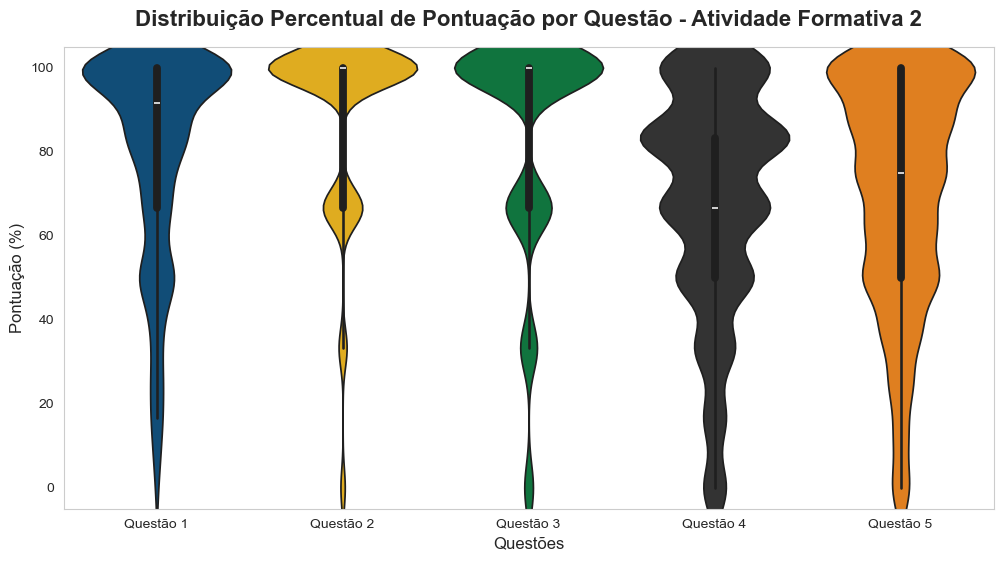

In [34]:
plt.figure(figsize=(12, 6))

# Usando as cores oficiais do PBA para manter o padrão
sns.violinplot(data=df_pedagogico[colunas_pct], palette=cores_pba[:len(colunas_pct)])

plt.title(f'Distribuição Percentual de Pontuação por Questão - {NOME_AVALIACAO}', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Pontuação (%)', fontsize=12)
plt.xlabel('Questões', fontsize=12)
plt.xticks(ticks=range(5), labels=['Questão 1', 'Questão 2', 'Questão 3', 'Questão 4', 'Questão 5'])
plt.ylim(-5, 105)

# Salvando gráfico
nome_grafico_2 = f'2_distribuicao_questoes_pontuacao_{PREFIXO_COLUNA}.png'
caminho_grafico_2 = os.path.join(dir_graficos, nome_grafico_2)

plt.savefig(caminho_grafico_2, dpi=300, bbox_inches='tight') # dpi=300 garante alta qualidade para relatórios/impressão
print(f"Gráfico salvo com sucesso em: {caminho_grafico_2}")
plt.show()


#### 2.3 Classificação Algorítmica das Questões
Utilizando a Teoria Clássica dos Testes associada ao **algoritmo K-Means**, agruparemos as questões em 3 níveis de dificuldade (Fácil, Intermediária e Difícil) baseando-nos puramente na média percentual de desempenho dos alfabetizandos.

In [35]:
# 1. Calculando a média percentual de cada questão
medias_questoes = df_pedagogico[colunas_pct].mean().to_frame(name='media_percentual')

# 2. Aplicando o algoritmo K-Means para criar 3 clusters (Fácil, Intermediária, Difícil)
kmeans = KMeans(n_clusters=3, random_state=42)
medias_questoes['cluster'] = kmeans.fit_predict(medias_questoes[['media_percentual']])

# 3. Mapeando os clusters para os rótulos de dificuldade
# O cluster com a maior média será o Fácil, o do meio Intermediário, e o menor Difícil.
medias_ordenadas = medias_questoes.groupby('cluster')['media_percentual'].mean().sort_values()

# Dicionário dinâmico para mapear o id do cluster para o nome correto
mapa_dificuldade = {
    medias_ordenadas.index[0]: 'Difícil',
    medias_ordenadas.index[1]: 'Intermediária',
    medias_ordenadas.index[2]: 'Fácil'
}

medias_questoes['classificacao_algoritmo'] = medias_questoes['cluster'].map(mapa_dificuldade)
medias_questoes = medias_questoes.sort_values(by='media_percentual', ascending=False).round(2)

print("Classificação gerada pelo algoritmo K-Means:")
display(medias_questoes[['media_percentual', 'classificacao_algoritmo']])


Classificação gerada pelo algoritmo K-Means:


,media_percentual,classificacao_algoritmo
forma_2_q2_pct,88.64,Fácil
forma_2_q3_pct,84.03,Fácil
forma_2_q1_pct,79.04,Intermediária
forma_2_q5_pct,70.69,Difícil
forma_2_q4_pct,68.34,Difícil


#### 2.3.1 Descobrindo o Agrupamento Natural (Método do Cotovelo)
Antes de definirmos a classificação em 3 níveis (Fácil, Intermediário, Difícil), vamos utilizar o **Método do Cotovelo** para observar como as questões se agrupam naturalmente com base em suas médias percentuais. Calcularemos a inércia do K-Means para diferentes quantidades de clusters ($k$).

Gráfico salvo com sucesso em: graficos_relatorio_2.2.1_forma_2/2_distribuicao_questoes_pontuacao_forma_2.png


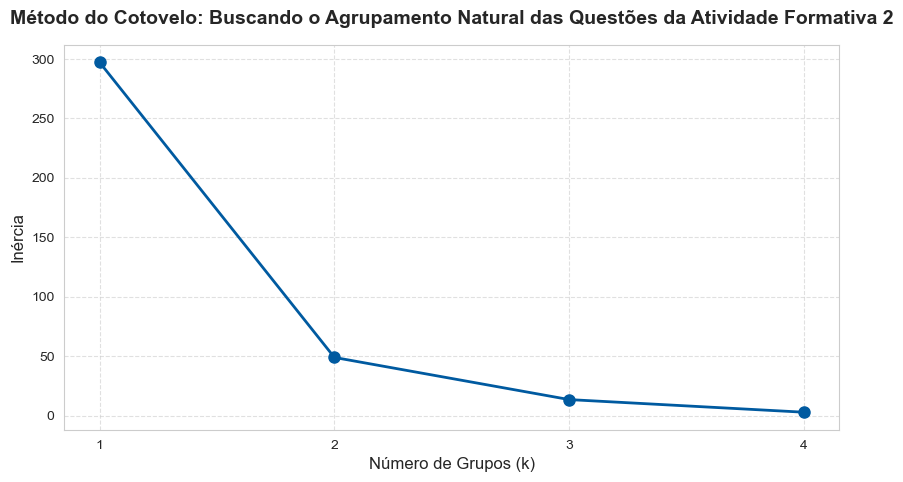

In [36]:
# Importando a biblioteca caso ainda não tenha importado
inercia = []
# Como temos apenas 5 questões, vamos testar k de 1 até 4
valores_k = range(1, 5)

for k in valores_k:
    # O n_init=10 é adicionado para evitar warnings em versões mais recentes do scikit-learn
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_teste.fit(medias_questoes[['media_percentual']])
    
    # inertia_ guarda a soma das distâncias quadradas dentro dos clusters
    inercia.append(kmeans_teste.inertia_)

# Plotando o gráfico do Método do Cotovelo
plt.figure(figsize=(10, 5))
plt.plot(valores_k, inercia, marker='o', linestyle='-', color='#005aa0', linewidth=2, markersize=8)

plt.title(f'Método do Cotovelo: Buscando o Agrupamento Natural das Questões da {NOME_AVALIACAO}', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Grupos (k)', fontsize=12)
plt.ylabel('Inércia', fontsize=12)
plt.xticks(valores_k)
plt.grid(True, linestyle='--', alpha=0.6)

# Salvando o gráfico
nome_grafico_3 = f'3_metodo_cotovelo_questoes_{PREFIXO_COLUNA}.png'
caminho_grafico_3 = os.path.join(dir_graficos, nome_grafico_3)

plt.savefig(caminho_grafico_3, dpi=300, bbox_inches='tight')
print(f"Gráfico salvo com sucesso em: {caminho_grafico_2}")
plt.show()


In [37]:
# 1. Pegamos os valores centrais (centroides) que o algoritmo encontrou e os ordenamos
centroides = kmeans.cluster_centers_.flatten()
centroides_ordenados = np.sort(centroides)

# 2. Calculamos o ponto médio entre os centroides para achar as fronteiras (notas de corte)
corte_dificil_inter = (centroides_ordenados[0] + centroides_ordenados[1]) / 2
corte_inter_facil = (centroides_ordenados[1] + centroides_ordenados[2]) / 2

print("--- REGRAS DE CLASSIFICAÇÃO DO ALGORITMO ---")
print(f"O algoritmo considerou os seguintes limites baseados na distância matemática:")
print(f"-> DIFÍCIL: Médias abaixo de {corte_dificil_inter:.2f}%")
print(f"-> INTERMEDIÁRIA: Médias entre {corte_dificil_inter:.2f}% e {corte_inter_facil:.2f}%")
print(f"-> FÁCIL: Médias acima de {corte_inter_facil:.2f}%")


--- REGRAS DE CLASSIFICAÇÃO DO ALGORITMO ---
O algoritmo considerou os seguintes limites baseados na distância matemática:
-> DIFÍCIL: Médias abaixo de 74.28%
-> INTERMEDIÁRIA: Médias entre 74.28% e 82.69%
-> FÁCIL: Médias acima de 82.69%


#### 2.4 Comparação: Realidade Analítica vs. Parâmetro Estabelecido
Nesta etapa, cruzaremos os resultados obtidos pelo algoritmo (baseado no desempenho real dos alunos) com o grau de dificuldade originalmente planejado para a avaliação.

In [38]:
# Adicionando a classificação estabelecida ao DataFrame
variavel_classificacao = f'classificacao_estabelecida_{PREFIXO_COLUNA}'
classificacao_estabelecida = globals()[variavel_classificacao]

# Aplicando o mapeamento
medias_questoes[variavel_classificacao] = medias_questoes.index.map(classificacao_estabelecida)

# Criando flag para saber se o algoritmo e o teste estão alinhados
medias_questoes['alinhamento'] = medias_questoes['classificacao_algoritmo'] == medias_questoes[variavel_classificacao]

# Formatando a tabela para exibição final
tabela_comparativa = medias_questoes[['media_percentual', variavel_classificacao, 'classificacao_algoritmo', 'alinhamento']].copy().sort_index()
tabela_comparativa.index = ['Questão 1', 'Questão 2', 'Questão 3', 'Questão 4', 'Questão 5'] # Ajuste na ordem se precisar
tabela_comparativa.columns = ['Média (%)', 'Dificuldade Planejada', 'Dificuldade Real (Algoritmo)', 'Alinhado?']

print("Comparativo Final de Dificuldade das Questões:")
display(tabela_comparativa)

# Opcional: Salvar a tabela comparativa em Excel para anexar ao relatório
caminho_comparativo = os.path.join(dir_graficos, f'3_comparativo_dificuldade_questoes_{PREFIXO_COLUNA}.xlsx')
tabela_comparativa.to_excel(caminho_comparativo)


Comparativo Final de Dificuldade das Questões:


,Média (%),Dificuldade Planejada,Dificuldade Real (Algoritmo),Alinhado?
Questão 1,79.04,Fácil,Intermediária,False
Questão 2,88.64,Fácil,Fácil,True
Questão 3,84.03,Intermediária,Fácil,False
Questão 4,68.34,Intermediária,Difícil,False
Questão 5,70.69,Difícil,Difícil,True


## 3. Avaliação Pedagógica e Resultados do Diagnóstico Inicial

Este capítulo detalha os resultados obtidos através da aplicação da Formativa em questão. De acordo com o **Termo de Referência do PBA SE 2026**, o monitoramento da rotina de alfabetização deve partir de uma base sólida de dados que identifique o nível de adesão ao que foi ensinado em sala durante os estudos da última unidade.

A análise a seguir foca:
- Entender a distribuição geral de turmas e alfabetizandos entre os municípios;
- Entender a distribuição geral dos alfabetizandos pelos níveis **N1 a N4**, permitindo que a coordenação pedagógica ajuste as aulas e as formações de acordo com a realidade de cada turma. 
- Entender a distribuição dos alfabetizandos pelos níveis **N1 a N4** para cada município;
- Entender a realidade de alfabetizandos na Formativa em questão que tiraram niveis **N3 ou N4** durante a atividade diagnóstica, buscando checar o verdadeiro nível de proficiencia desses alfabetizandos ou entender se houve interferência do auxílio do alfabetizador na determinação do nível de alfabetização inicial.

### 3.1 Cobertura Territorial: Turmas e Alunos por Município

Para o monitoramento da rotina de alfabetização, é essencial cruzar o número de turmas ativas com o volume de alunos. Esta análise permite identificar a densidade do programa em cada localidade e verificar a conformidade com as metas de atendimento.


In [39]:
# Configurações de estilo e paleta
sns.set_style("whitegrid", {'axes.grid' : False}) # Grid personalizado

# Consolidação de Dados por Município
# Criando um resumo por município a partir do df_turmas
resumo_municipios = df_turmas.groupby('municipio').agg(
    qtd_turmas=('turma', 'count'),
    total_alunos=('qtd_alfabetizandos', 'sum')
).sort_values(by='total_alunos', ascending=False).reset_index()

# Salvando arquivo
nome_do_arquivo_1 = 'turmas_e_alfabetizandos_por_municipio.xlsx'
caminho_excel_1 = os.path.join(dir_graficos, nome_do_arquivo_1)
resumo_municipios.to_excel(caminho_excel_1, index=False)

print(f"Planilha salva com sucesso em: {caminho_excel_1}")

# Checando turmas com Formativas registradas
alunos_com_formativa = df_pedagogico.dropna(subset=[f'{PREFIXO_COLUNA}_result'])
turmas_com_formativa = alunos_com_formativa['turma'].unique()
turmas_sem_formativa = list(set(df_pedagogico['turma'].unique()) - set(turmas_com_formativa))

# Imprimindo resultados
print(f'Quantidade de turmas no programa: {resumo_municipios["qtd_turmas"].sum()}')
print(f'Quantidade de municípios atendidos: {resumo_municipios.shape[0]}')
print(f'Quantidade de turmas com resultados de Formativa {NUM_FORMATIVA}: {len(turmas_com_formativa)}')
print(f'Turmas sem resultados de Formativa {NUM_FORMATIVA}: {turmas_sem_formativa}')
print(f'Quantidade de municipios com turmas com resultados de Formativa {NUM_FORMATIVA}: {len(alunos_com_formativa['municipio'].unique())}')
print("Resumo de Distribuição por Município:")
display(resumo_municipios)


Planilha salva com sucesso em: graficos_relatorio_2.2.1_forma_2/turmas_e_alfabetizandos_por_municipio.xlsx
Quantidade de turmas no programa: 138
Quantidade de municípios atendidos: 31
Quantidade de turmas com resultados de Formativa 2: 137
Turmas sem resultados de Formativa 2: []
Quantidade de municipios com turmas com resultados de Formativa 2: 31
Resumo de Distribuição por Município:


,municipio,qtd_turmas,total_alunos
0,ARACAJU,18,317
1,LAGARTO,17,295
2,SIMÃO DIAS,13,230
3,PORTO DA FOLHA,10,224
4,ITABAIANA,9,219
5,MONTE ALEGRE DE SERGIPE,6,124
6,SÃO CRISTÓVÃO,7,120
7,ESTÂNCIA,6,100
8,POÇO VERDE,5,99
9,ITABAIANINHA,5,90


Gráfico salvo com sucesso em: graficos_relatorio_2.2.1_forma_2/4_numero_de_turmas_e_alunos_por_municipio.png


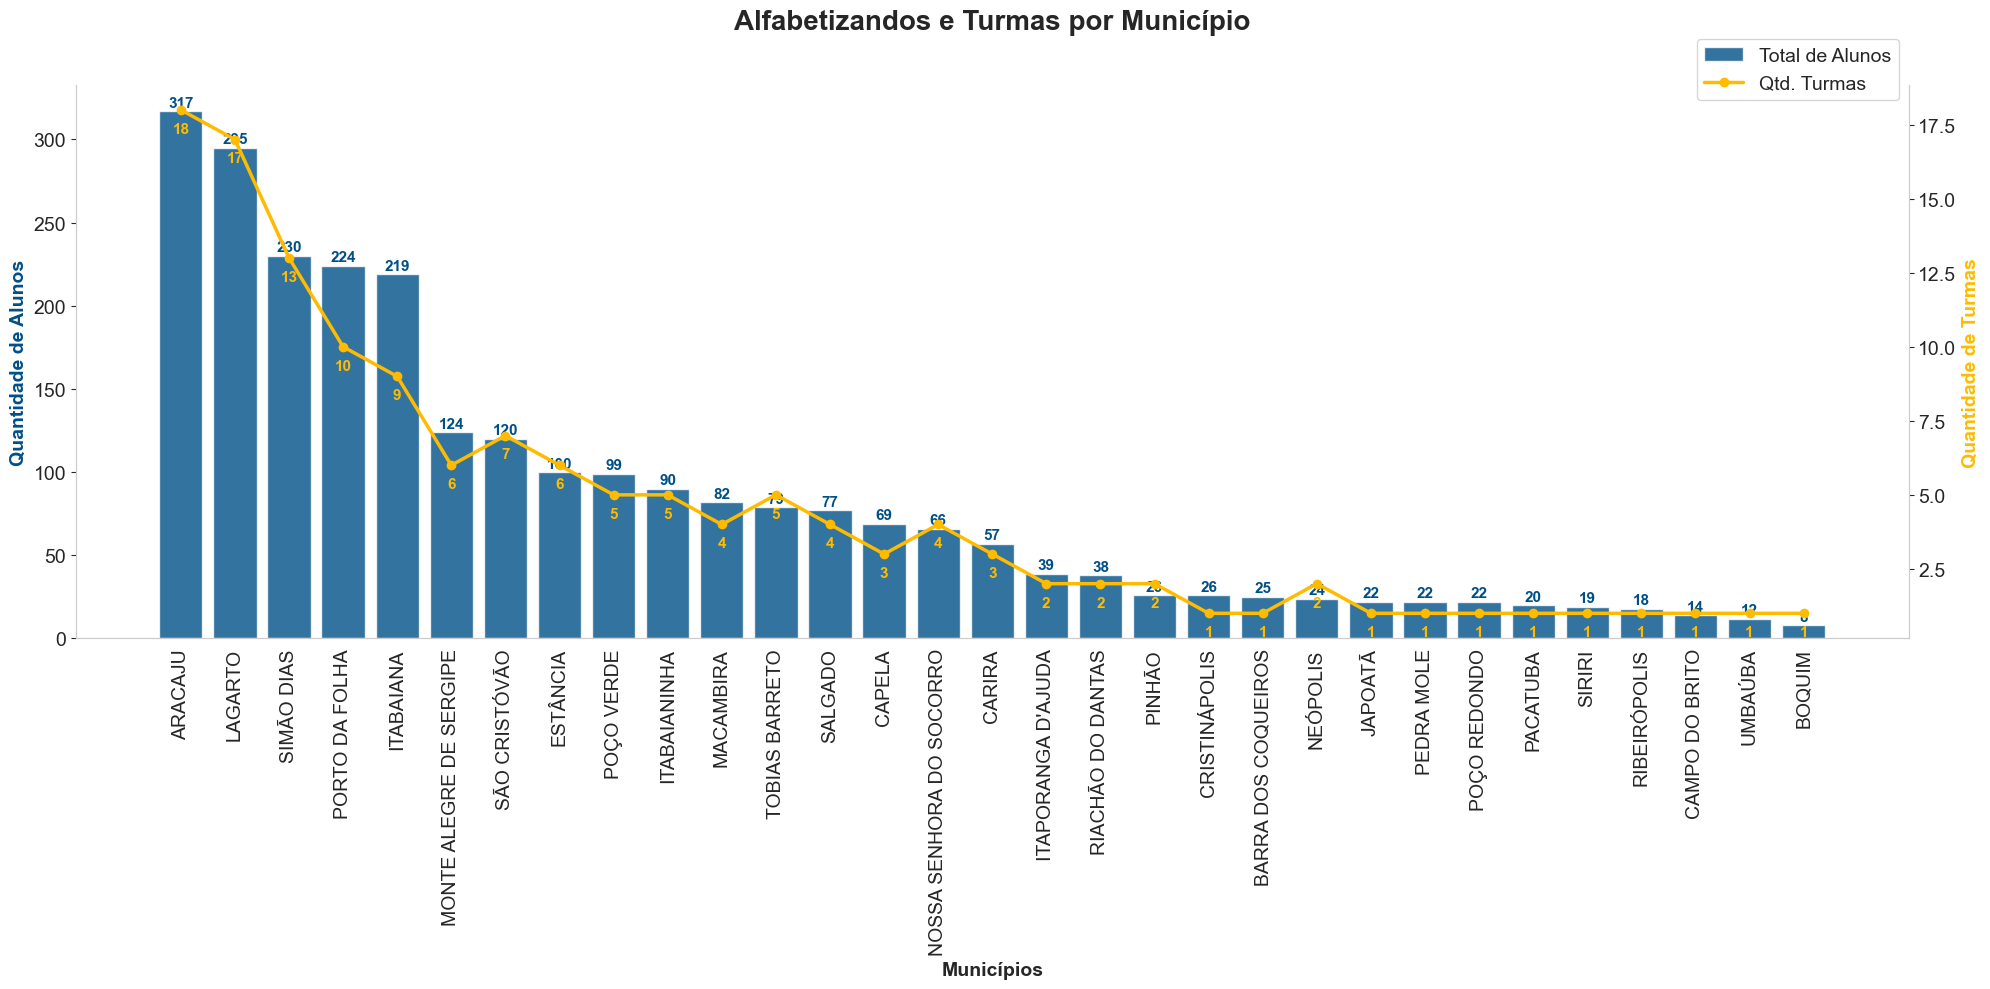

In [40]:
# Preparação dos dados para criação de gráfico de turmas e alfabetizandos(Garantindo que todos os municípios sejam incluídos)
resumo_completo = resumo_municipios.copy() # Usando o DF que criamos anteriormente
x_labels = resumo_completo['municipio'].values

# Configuração do gráfico
fig, ax1 = plt.subplots(figsize=(20, 10)) # Aumentamos a largura para caber todos

# --- EIXO 1: ALUNOS (BARRAS) ---
barras = ax1.bar(x_labels, resumo_completo['total_alunos'], color="#005088", label='Total de Alunos', alpha=0.8)
ax1.set_ylabel('Quantidade de Alunos', color="#005088", fontsize=14, fontweight='bold')
ax1.set_xlabel('Municípios', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)

# Rótulos das barras (Alunos) - No topo das barras
ax1.bar_label(barras, padding=1, color="#005088", fontweight='bold', fontsize=11)

# Configuração do Eixo X para mostrar TODOS os nomes
ax1.set_xticks(range(len(x_labels)))
ax1.set_xticklabels(x_labels, rotation=90, fontsize=14)

# --- EIXO 2: TURMAS (LINHA) ---
ax2 = ax1.twinx()
linha = ax2.plot(x_labels, resumo_completo['qtd_turmas'], color="#FFBB00", marker='o', 
                 linewidth=2.5, markersize=6, label='Qtd. Turmas')
ax2.set_ylabel('Quantidade de Turmas', color="#FFBB00", fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelsize=14)

# Rótulos da linha (Turmas) - ABAIXO do ponto e na COR #FFBB00
for i, valor in enumerate(resumo_completo['qtd_turmas']):
    ax2.text(i, valor - 0.4, str(int(valor)), color="#FFBB00", 
             ha='center', va='top', fontweight='bold', fontsize=11)

# Unificando as legendas
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right', bbox_to_anchor=(1, 1.1), fontsize=14)

plt.title('Alfabetizandos e Turmas por Município', fontsize=20, pad=40, fontweight='bold')
plt.tight_layout()
sns.despine(right=False)

# Salvando o gráfico em dir_graficos
nome_grafico_4 = '4_numero_de_turmas_e_alunos_por_municipio.png'
caminho_grafico_4 = os.path.join(dir_graficos, nome_grafico_4)

plt.savefig(caminho_grafico_4, dpi=300, bbox_inches='tight') # dpi=300 garante alta qualidade para relatórios/impressão
print(f"Gráfico salvo com sucesso em: {caminho_grafico_4}")
plt.show()


### 3.2 Níveis adesão ao conteúdo estudado (Formativa)

Para fins deste relatório, a classificação segue os critérios estabelecidos pela FGV DGPE:
* **N1:** Identifica sílabas com apoio e reconhece palavras simples sem leitura autônoma.
* **N2** Reconhece o número de sílabas e identifica sílabas iguais com apoio.
* **N3:** Decodifica palavras formadas por sílabas simples de forma lenta e silabada, com apoio.
* **N4:** Lê palavras simples, ainda sem fluência e sem autonomia, demonstrando avanço na relação letra–som.

Total de alunos que realizaram a Atividade Formativa 2: 2518


/tmp/ipykernel_49846/686532447.py:10: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.countplot(


Gráfico salvo com sucesso em: graficos_relatorio_2.2.1_forma_2/5_distribuicao_geral_forma_2.png


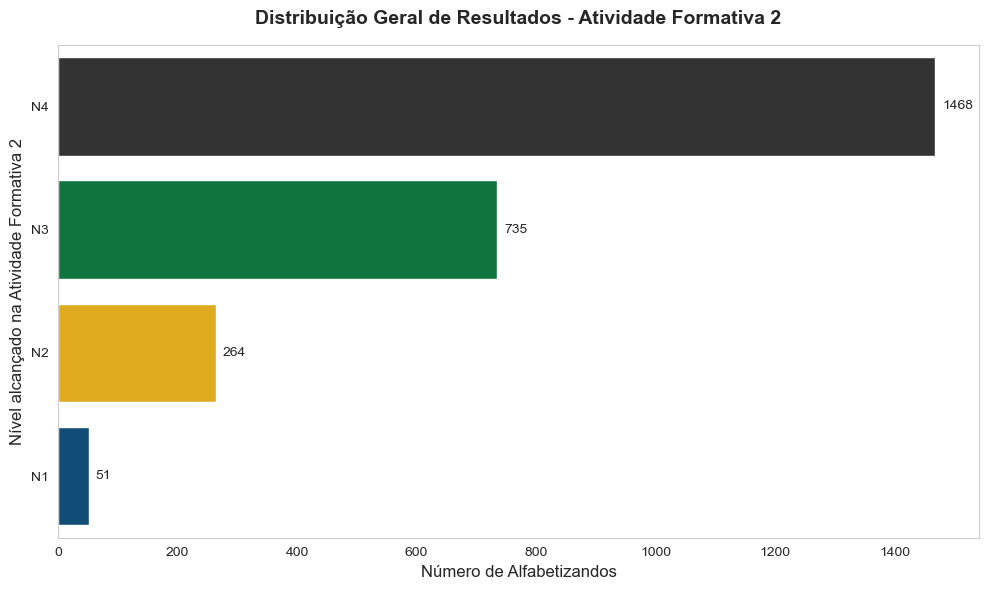

In [41]:
# 1. Filtrar apenas os alunos que realizaram a Formativa 1
df_formativa = df_pedagogico.dropna(subset=[f'{PREFIXO_COLUNA}_result_resum']).copy()

print(f"Total de alunos que realizaram a {NOME_AVALIACAO}: {df_formativa.shape[0]}")

# 2. Configurar e criar o gráfico
plt.figure(figsize=(10, 6))
ordem_fixa = ['N4', 'N3', 'N2', 'N1']  # Ordem desejada dos níveis

sns.countplot(
    y=f'{PREFIXO_COLUNA}_result_resum', 
    data=df_formativa, 
    order=ordem_fixa, 
    palette=cores_pba,
    hue=f'{PREFIXO_COLUNA}_result_resum', # Evitar warning da paleta
    legend=False
)

plt.title(f'Distribuição Geral de Resultados - {NOME_AVALIACAO}', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Alfabetizandos', fontsize=12)
plt.ylabel(f'Nível alcançado na {NOME_AVALIACAO}', fontsize=12)

# Adicionar os valores exatos em cada barra para ficar mais profissional
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), textcoords='offset points', fontsize=10)
    
# Salvando o gráfico
nome_grafico_5 = f'5_distribuicao_geral_{PREFIXO_COLUNA.lower().replace(" ", "_")}.png'
caminho_grafico_5 = os.path.join(dir_graficos, nome_grafico_5)

plt.savefig(caminho_grafico_5, dpi=300, bbox_inches='tight')
print(f"Gráfico salvo com sucesso em: {caminho_grafico_5}")

plt.tight_layout()
plt.show()


### 3.3 Resultados da Formativa por Município (Geração de Gráficos Individuais)

Para subsidiar as equipes técnicas locais, automatizamos a geração de gráficos de desempenho para cada um dos municípios parceiros. 

**Processo de Automação:**
1. O código identifica todos os municípios únicos na base de dados.
2. Filtra os alfabetizandos ativos de cada localidade.
3. Gera um gráfico horizontal respeitando a identidade visual do PBA.
4. Salva o arquivo `.png` no diretório de saída (`dir_graficos`) para inclusão automática nos relatórios municipais.

In [42]:
# Lista de municípios únicos
municipios = sorted(df_pedagogico['municipio'].unique())

# Gerando loop para criar um gráfico para cada município
print(f"Iniciando a geração de gráficos padronizados para {len(municipios)} municípios...")

for muni in municipios:
    df_muni = df_formativa[df_formativa['municipio'] == muni]
    
    # Agrupar dados
    resultado_muni = df_muni.groupby([f'{PREFIXO_COLUNA}_result_resum'], observed=False)['cpf'].count().reset_index()
    resultado_muni.columns = [f'resultado_{PREFIXO_COLUNA}', 'numero_alfabetizandos']
    
    # Mantemos o figsize similar ao seu gráfico geral para proporção
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # --- AJUSTE DE ESPESSURA ---
    sns.barplot(
        data=resultado_muni, 
        x='numero_alfabetizandos', 
        y=f'resultado_{PREFIXO_COLUNA}', 
        palette=cores_pba,
        hue=f'resultado_{PREFIXO_COLUNA}', # Colorir a barra com base no resultado
        order=ordem_fixa, # ESSENCIAL: Garante que o eixo Y tenha sempre 4 posições
        height=0.8,       # FIXA A ESPESSURA: 0.8 é a largura padrão do Seaborn
        ax=ax
    )
    
    # Adicionar rótulos (Loop em todos os containers)
    for container in ax.containers:
        ax.bar_label(container, padding=10, fontweight='bold', color='#333333')
    
    # Títulos e Estética (Seguindo seu padrão)
    ax.set_title(f'Resultados da {NOME_AVALIACAO} em {muni}', fontsize=14, pad=15, fontweight='bold', color="#005088")
    ax.set_xlabel('Quantidade de Alunos', fontsize=10)
    ax.set_ylabel(f'Nível alcançado na {NOME_AVALIACAO}', fontsize=10)
    
    # Ajuste de margem (1.4 garante espaço para o rótulo à direita)
    max_val = resultado_muni['numero_alfabetizandos'].max()
    ax.set_xlim(0, (max_val * 1.4) if max_val > 0 else 10)
    
    sns.despine()
    plt.tight_layout()
    
    # Salvando o arquivos no diretório dir_graficos
    nome_arquivo = f"{PREFIXO_COLUNA.lower().replace(' ', '_')}_{muni.lower().replace(' ', '_')}.png"
    caminho_salvamento = os.path.join(dir_graficos, nome_arquivo)
    
    plt.savefig(caminho_salvamento, dpi=300, bbox_inches='tight')
    plt.close(fig)
    
# Criando resultados por municípios
tabela_resultados_municipios = pd.pivot_table(
    df_formativa,
    index='municipio',           # O que vai ficar nas linhas
    columns=f'{PREFIXO_COLUNA}_result_resum',    # O que vai ficar nas colunas (N1, N2, N3, N4)
    values='cpf',                # O que vai ser contado (alunos)
    aggfunc='nunique',              # A operação: contar a quantidade de linhas (alunos)
    fill_value=0                 # Preencher com 0 onde não houver alunos (em vez de NaN)
)

# Adicionar uma coluna de 'Total' para enriquecer a tabela
tabela_resultados_municipios['Total'] = tabela_resultados_municipios.sum(axis=1)

# Ordenar a tabela pela quantidade total de alunos no município (do maior para o menor)
tabela_resultados_municipios = tabela_resultados_municipios.sort_values(by='Total', ascending=False)

# Salvando o arquivo no diretório dir_graficos
nome_do_arquivo_3 = f'{PREFIXO_COLUNA.lower().replace(" ", "_")}_resultados_por_municipio.xlsx'
caminho_excel_3 = os.path.join(dir_graficos, nome_do_arquivo_3)
tabela_resultados_municipios.to_excel(caminho_excel_3, index=True)

print(f"Sucesso! Gráficos com espessura padronizada salvos em: {dir_graficos}")
display(tabela_resultados_municipios.head())


Iniciando a geração de gráficos padronizados para 31 municípios...


/tmp/ipykernel_49846/921386132.py:18: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_49846/921386132.py:18: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_49846/921386132.py:18: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_49846/921386132.py:18: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_49846/921386132.py:18: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_49846/921386132.py:18: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_49846/921386132.py:18: UserWarning: The palette list has more values (11) than needed (4), which 

Sucesso! Gráficos com espessura padronizada salvos em: graficos_relatorio_2.2.1_forma_2


/tmp/ipykernel_49846/921386132.py:53: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabela_resultados_municipios = pd.pivot_table(


forma_2_result_resum,N1,N2,N3,N4,Total
municipio,,,,,
ARACAJU,21,33,98,155,307
LAGARTO,7,38,102,145,292
SIMÃO DIAS,3,20,73,127,223
PORTO DA FOLHA,5,48,57,110,220
ITABAIANA,7,36,50,126,219


### 3.4 Transição de Aprendizagem: O Desempenho dos Estudantes N3 e N4

Uma questão central para a nossa estratégia pedagógica é perceber o que acontece com os alunos que iniciam o programa com um nível mais avançado (Níveis N3 ou N4 na Avaliação Diagnóstica). Será que a Formativa em questão demonstrou que eles evoluíram, mantiveram o nível ou regrediram?

Abaixo, isolamos o grupo de alunos "N3 ou N4" da avaliação de entrada e cruzamos com os resultados que obtiveram agora na Formativa 1 através de uma **Matriz de Transição**.

/tmp/ipykernel_49846/554348343.py:11: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.countplot(


Total de alunos (N3 ou N4 na entrada) que realizaram a Formativa 1: 965

Gráfico salvo com sucesso em: graficos_relatorio_2.2.1_forma_2/6_desempenho_na_forma_2_apenas_alunos_n3_e_n4_na_entrada.png


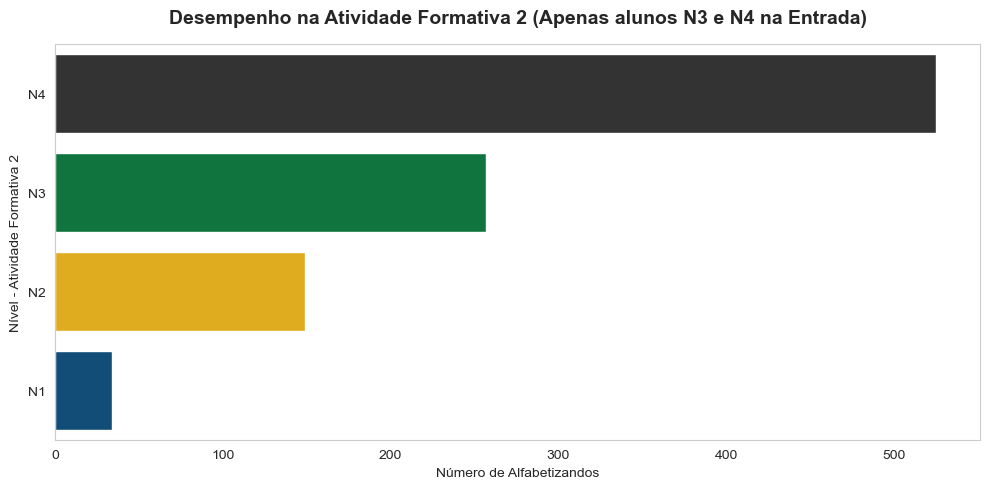


--- Matriz de Transição (Quantidade de Alunos): Diagnóstica de Entrada -> Atividade Formativa 2 ---


forma_2_result_resum,N1,N2,N3,N4,Total Geral
diag_entr_result,,,,,
N3 | Reconhece algumas letras do alfabeto,4,24,132,373,533
N4 | Identifica o número de sílabas de palavras com apoio,1,27,76,295,399
Total Geral,5,51,208,668,932


In [43]:
# 1. Filtrar alunos que tiraram N3 ou N4 na diagnóstica
n3_n4_diagnostica = df_pedagogico[df_pedagogico['diag_entr_result_resum'].str.contains('N3|N4', na=False, regex=True)].copy()

# 2. Remover quem não fez a formativa 1 dentro deste grupo
n3_n4_diagnostica = n3_n4_diagnostica.dropna(subset=['forma_1_result_resum'])

print(f"Total de alunos (N3 ou N4 na entrada) que realizaram a Formativa 1: {n3_n4_diagnostica.shape[0]}\n")

# 3. Plotar o desempenho específico destes alunos na Formativa 1
plt.figure(figsize=(10, 5))
sns.countplot(
    y='forma_1_result_resum', 
    data=n3_n4_diagnostica, 
    order=ordem_fixa, 
    palette=cores_pba,
    hue='forma_1_result_resum',
    legend=False
)
plt.title(f'Desempenho na {NOME_AVALIACAO} (Apenas alunos N3 e N4 na Entrada)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Alfabetizandos')
plt.ylabel(f'Nível - {NOME_AVALIACAO}')

# Salvando o gráfico
nome_grafico_6 = f'6_desempenho_na_{PREFIXO_COLUNA.lower().replace(" ", "_")}_apenas_alunos_n3_e_n4_na_entrada.png'
caminho_grafico_6 = os.path.join(dir_graficos, nome_grafico_6)

plt.savefig(caminho_grafico_6, dpi=300, bbox_inches='tight')
print(f"Gráfico salvo com sucesso em: {caminho_grafico_6}")

plt.tight_layout()
plt.show()

# 4. Gerar a Matriz de Transição
print(f"\n--- Matriz de Transição (Quantidade de Alunos): Diagnóstica de Entrada -> {NOME_AVALIACAO} ---")
matriz_transicao = pd.crosstab(
    n3_n4_diagnostica['diag_entr_result'], 
    n3_n4_diagnostica[f'{PREFIXO_COLUNA}_result_resum'], 
    margins=True, 
    margins_name="Total Geral"
)

# Estilizando a tabela para destacar os números com cores
cm = sns.light_palette("purple", as_cmap=True)
tabela_estilizada = matriz_transicao.style.background_gradient(cmap=cm)

display(tabela_estilizada)


### 3.5 Cálculo do Índice de Progressão de Aprendizagem (IPA) - Formativa

Com os relatórios de notas consolidados, vamos calcular o **IPA** para a Formativa em questão. Diferente de uma média simples, o IPA isola o desempenho do alfabetizando em cada prática de linguagem e aplica a regra de progressão contínua na Zona de Desenvolvimento Proximal (ZPD).

A fórmula fundamental de consolidação do sub-nível é:
$$IPA_{i,p} = \max\left(IPA_{i-1,p}, i \times S_{i,p}\right)$$

**Passos executados neste bloco:**
1. **Mapeamento de Questões:** Somamos os acertos agrupando pelas práticas (Oralidade e Leitura, Produção Escrita e Análise Linguística) de acordo com os descritores avaliados em cada questão da F1.
2. **Cálculo do Percentual ($S$):** Dividimos a soma obtida pelo teto máximo de cada prática.
3. **Ponderação Global:** Consolidamos o IPA Global atribuindo **45%** para Escrita, **40%** para Leitura e **15%** para Análise Linguística.
4. **Classificação:** Categorizamos o resultado em 4 níveis pedagógicos com bandas flexíveis para absorver pequenas margens de erro.

In [44]:
# Calculando IPA de qualquer Formativa (dinâmico)
def calcular_ipa_geral(df, num_formativa=None):
    
    # Se nenhum número for passado explicitamente, ele puxa a global
    if num_formativa is None:
        num_formativa = NUM_FORMATIVA
        
    prefixo_coluna = f'forma_{num_formativa}'
    
    # 1. Calculando as pontuações brutas da Formativa em análise
    nome_funcao_calculo_ipa = f'calcular_ipa_{prefixo_coluna}'
    df = df.pipe(globals()[nome_funcao_calculo_ipa])
    
    # 2. Definir os Parâmetros (Tetos Máximos) da formativa em análise
    tetos_formativa = globals()[f'tetos_{prefixo_coluna}']
    
    # --- AJUSTE DINÂMICO DA BASE ---
    if num_formativa > 1:
        num_formativa_anterior = num_formativa - 1
        
        # O prefixo de onde vamos puxar o nível base para não deixar a nota cair
        base_ol = f'ipa_ol_f{num_formativa_anterior}'
        base_pe = f'ipa_pe_f{num_formativa_anterior}'
        base_al = f'ipa_al_f{num_formativa_anterior}'
        
        # Se os IPAs da formativa anterior ainda não existirem na tabela, chamamos esta MESMA função para calculá-los antes de prosseguir!
        if base_ol not in df.columns:
            df = calcular_ipa_geral(df, num_formativa=num_formativa_anterior)
            
    else:
        # Se for a Formativa 1, inicializa a diagnóstica caso não exista
        for pratica in ['ol', 'pe', 'al']:
            col_name = f'ipa_diagnostica_{pratica}'
            if col_name not in df.columns:
                df[col_name] = 1.0 # Nível base
        
        base_ol = 'ipa_diagnostica_ol'
        base_pe = 'ipa_diagnostica_pe'
        base_al = 'ipa_diagnostica_al'
    # ------------------------------------------------
    
    # 3. Calcular o Percentual de Acerto (S) na Formativa Atual
    df[f's_ol_f{num_formativa}'] = df[f'pontuacao_ol_f{num_formativa}'] / tetos_formativa['ol']
    df[f's_pe_f{num_formativa}'] = df[f'pontuacao_pe_f{num_formativa}'] / tetos_formativa['pe']
    df[f's_al_f{num_formativa}'] = df[f'pontuacao_al_f{num_formativa}'] / tetos_formativa['al']

    # 4. Calcular o Sub-nível de Cada Prática (IPA por Prática) com base na linha de base escolhida
    df[f'ipa_ol_f{num_formativa}'] = np.maximum(df[base_ol], num_formativa * df[f's_ol_f{num_formativa}'])
    df[f'ipa_pe_f{num_formativa}'] = np.maximum(df[base_pe], num_formativa * df[f's_pe_f{num_formativa}'])
    df[f'ipa_al_f{num_formativa}'] = np.maximum(df[base_al], num_formativa * df[f's_al_f{num_formativa}'])

    # 5. Calcular o IPA Global (Índice Composto)
    df[f'ipa_global_f{num_formativa}'] = (
        (pesos['pe'] * df[f'ipa_pe_f{num_formativa}']) + 
        (pesos['ol'] * df[f'ipa_ol_f{num_formativa}']) + 
        (pesos['al'] * df[f'ipa_al_f{num_formativa}'])
    ).round(2)

    # 6. Classificação Pedagógica
    df[f'classificacao_ipa_f{num_formativa}'] = pd.cut(
        df[f'ipa_global_f{num_formativa}'], 
        bins=limites_ajustados, 
        labels=rotulos, 
        right=True
    )

    # Ordenando categorias
    df[f'classificacao_ipa_f{num_formativa}'] = pd.Categorical(
        df[f'classificacao_ipa_f{num_formativa}'], 
        categories=rotulos, 
        ordered=True
    )

    # 7. Visualização Final
    colunas_visualizacao = [
        f'pontuacao_ol_f{num_formativa}', 
        f'pontuacao_pe_f{num_formativa}', 
        f'pontuacao_al_f{num_formativa}', 
        f'ipa_global_f{num_formativa}',
        f'classificacao_ipa_f{num_formativa}'
    ]
    
    print(f"\n--- Amostra de Alunos: Formativa {num_formativa} ---")
    display(df[colunas_visualizacao].head(10))
    print(f"\n--- Total de Alunos por Classificação (Formativa {num_formativa}) ---")
    
    # Criamos um DataFrame temporário para juntar a contagem e a porcentagem
    contagem = df[f'classificacao_ipa_f{num_formativa}'].value_counts()
    porcentagem = df[f'classificacao_ipa_f{num_formativa}'].value_counts(normalize=True) * 100
    
    resumo_classificacao = pd.DataFrame({
        'Quantidade': contagem,
        'Percentual (%)': porcentagem.round(2)
    })
    
    display(resumo_classificacao)
    print("-" * 50)
        
    return df

# Aplicando a função para calcular o IPA geral da Formativa
df_formativa = calcular_ipa_geral(df_formativa)



--- Amostra de Alunos: Formativa 1 ---


,pontuacao_ol_f1,pontuacao_pe_f1,pontuacao_al_f1,ipa_global_f1,classificacao_ipa_f1
0,30.0,30.0,11.0,1.0,Iniciante
1,24.0,24.0,6.0,1.0,Iniciante
2,29.0,29.0,11.0,1.0,Iniciante
3,32.0,32.0,11.0,1.0,Iniciante
4,31.0,31.0,11.0,1.0,Iniciante
5,28.0,28.0,8.0,1.0,Iniciante
6,27.0,27.0,9.0,1.0,Iniciante
7,27.0,27.0,8.0,1.0,Iniciante
8,30.0,30.0,10.0,1.0,Iniciante
9,24.0,24.0,5.0,1.0,Iniciante



--- Total de Alunos por Classificação (Formativa 1) ---


,Quantidade,Percentual (%)
classificacao_ipa_f1,,
Iniciante,2518,100.0
Em desenvolvimento,0,0.0
Alfabetizado(a),0,0.0
Alfabetização consolidada,0,0.0


--------------------------------------------------

--- Amostra de Alunos: Formativa 2 ---


,pontuacao_ol_f2,pontuacao_pe_f2,pontuacao_al_f2,ipa_global_f2,classificacao_ipa_f2
0,11.0,13.0,17.0,1.85,Em desenvolvimento
1,7.0,10.0,14.0,1.34,Iniciante
2,11.0,13.0,16.0,1.84,Em desenvolvimento
3,12.0,14.0,18.0,2.00,Em desenvolvimento
4,11.0,13.0,18.0,1.87,Em desenvolvimento
5,8.0,13.0,15.0,1.62,Em desenvolvimento
6,10.0,10.0,17.0,1.59,Em desenvolvimento
7,8.0,13.0,14.0,1.60,Em desenvolvimento
8,11.0,12.0,18.0,1.80,Em desenvolvimento
9,8.0,10.0,14.0,1.41,Iniciante



--- Total de Alunos por Classificação (Formativa 2) ---


,Quantidade,Percentual (%)
classificacao_ipa_f2,,
Em desenvolvimento,1445,57.39
Iniciante,1073,42.61
Alfabetizado(a),0,0.00
Alfabetização consolidada,0,0.00


--------------------------------------------------


/tmp/ipykernel_49846/3525749051.py:6: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.countplot(


Gráfico salvo com sucesso em: graficos_relatorio_2.2.1_forma_2/7_ipa_forma_2_geral.png


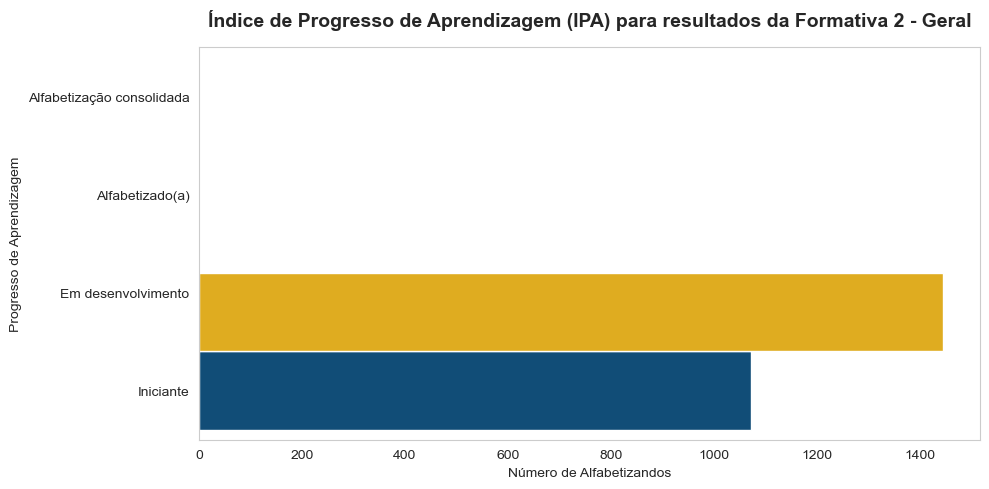

In [45]:
# Criando ordem mais adequada de exposição de classificação de IPA no gráfico
ordem_descricao_ipa = ['Alfabetização consolidada', 'Alfabetizado(a)', 'Em desenvolvimento', 'Iniciante']

# Plotar o desempenho específico destes alunos na Formativa 1
plt.figure(figsize=(10, 5))
sns.countplot(
    y=f'classificacao_ipa_f{NUM_FORMATIVA}', 
    data=df_formativa, 
    order=ordem_descricao_ipa,
    palette=cores_pba,
    hue=f'classificacao_ipa_f{NUM_FORMATIVA}',
    height=0.8,       # FIXA A ESPESSURA: 0.8 é a largura padrão do Seaborn
    legend=False
)
plt.title(f'Índice de Progresso de Aprendizagem (IPA) para resultados da Formativa {NUM_FORMATIVA} - Geral', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Alfabetizandos')
plt.ylabel('Progresso de Aprendizagem')

# Salvando o gráfico
nome_grafico_7 = f'7_ipa_{PREFIXO_COLUNA}_geral.png'
caminho_grafico_7 = os.path.join(dir_graficos, nome_grafico_7)

plt.savefig(caminho_grafico_7, dpi=300, bbox_inches='tight')
print(f"Gráfico salvo com sucesso em: {caminho_grafico_7}")

plt.tight_layout()
plt.show()


In [46]:
# Gerando loop para criar um gráficos de IPA para cada município
print(f"Iniciando a geração de gráficos padronizados de IPA para {len(municipios)} municípios...")

for muni in municipios:
    df_muni = df_formativa[df_formativa['municipio'] == muni]
    
    # Agrupar dados
    ipa_forma_municipios = df_muni.groupby(['municipio', f'classificacao_ipa_f{NUM_FORMATIVA}'], observed=False)['cpf'].nunique().reset_index()
    ipa_forma_municipios.columns = ['municipio', f'classificacao_ipa_f{NUM_FORMATIVA}', f'numero_alfabetizandos_f{NUM_FORMATIVA}']
    
    # Mantemos o figsize similar ao seu gráfico geral para proporção
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # --- AJUSTE DE ESPESSURA ---
    sns.barplot(
        data=ipa_forma_municipios, 
        x=f'numero_alfabetizandos_f{NUM_FORMATIVA}', 
        y=f'classificacao_ipa_f{NUM_FORMATIVA}', 
        palette=cores_pba,
        hue=f'classificacao_ipa_f{NUM_FORMATIVA}', # Colorir a barra com base na classificação IPA
        order=ordem_descricao_ipa, # ESSENCIAL: Garante que o eixo Y tenha sempre 4 posições
        height=0.8,       # FIXA A ESPESSURA: 0.8 é a largura padrão do Seaborn
        ax=ax
    )
    
    # Adicionar rótulos (Loop em todos os containers)
    for container in ax.containers:
        ax.bar_label(container, padding=10, fontweight='bold', color='#333333')
    
    # Títulos e Estética (Seguindo seu padrão)
    ax.set_title(f'IPA para Turmas em {muni}', fontsize=14, pad=15, fontweight='bold', color="#005088")
    ax.set_xlabel('Quantidade de Alunos', fontsize=10)
    ax.set_ylabel('Progresso de Aprendizagem', fontsize=10)
    
    # Ajuste de margem (1.4 garante espaço para o rótulo à direita)
    max_val = ipa_forma_municipios[f'numero_alfabetizandos_f{NUM_FORMATIVA}'].max()
    ax.set_xlim(0, (max_val * 1.4) if max_val > 0 else 10)
    
    sns.despine()
    plt.tight_layout()
    
    # Salvando o arquivos no diretório dir_graficos
    nome_arquivo = f"IPA_{PREFIXO_COLUNA}_{muni.lower().replace(' ', '_')}.png"
    caminho_salvamento = os.path.join(dir_graficos, nome_arquivo)
    
    plt.savefig(caminho_salvamento, dpi=300, bbox_inches='tight')
    plt.close(fig)
    
# Criando resultados por municípios
ipa_resultados_municipios = pd.pivot_table(
    df_formativa,
    index='municipio',           # O que vai ficar nas linhas
    columns=f'classificacao_ipa_f{NUM_FORMATIVA}', 
    values='cpf',                # O que vai ser contado (alunos)
    aggfunc='nunique',              # A operação: contar a quantidade de linhas (alunos)
    fill_value=0,                 # Preencher com 0 onde não houver alunos (em vez de NaN)
    observed=False
) # Reseta o índice para transformar 'municipio' em coluna normal

# Adicionar uma coluna de 'Total' para enriquecer a tabela
ipa_resultados_municipios['Total'] = ipa_resultados_municipios.sum(axis=1)

# Ordenar a tabela pela quantidade total de alunos no município (do maior para o menor)
ipa_resultados_municipios = ipa_resultados_municipios.sort_values(by='Total', ascending=False)

# Salvando o arquivo no diretório dir_graficos
nome_do_arquivo_4 = f'IPA_{PREFIXO_COLUNA}_resultados_por_municipio.xlsx'
caminho_excel_4 = os.path.join(dir_graficos, nome_do_arquivo_4)
ipa_resultados_municipios.to_excel(caminho_excel_4, index=True)

print(f"Sucesso! Gráficos com espessura padronizada salvos em: {dir_graficos}")
display(ipa_resultados_municipios.head())


Iniciando a geração de gráficos padronizados de IPA para 31 municípios...


/tmp/ipykernel_49846/2452948997.py:15: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_49846/2452948997.py:15: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_49846/2452948997.py:15: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_49846/2452948997.py:15: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_49846/2452948997.py:15: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_49846/2452948997.py:15: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_49846/2452948997.py:15: UserWarning: The palette list has more values (11) than needed (4),

Sucesso! Gráficos com espessura padronizada salvos em: graficos_relatorio_2.2.1_forma_2


classificacao_ipa_f2,Iniciante,Em desenvolvimento,Alfabetizado(a),Alfabetização consolidada,Total
municipio,,,,,
ARACAJU,138,169,0,0,307
LAGARTO,153,139,0,0,292
SIMÃO DIAS,108,115,0,0,223
PORTO DA FOLHA,109,111,0,0,220
ITABAIANA,84,135,0,0,219


## 4. Monitoramento de Metas de Enturmação (Conformidade com o TR)

O Termo de Referência do PBA SE 2026 estipula limites para a formação das turmas, visando garantir a qualidade pedagógica e a otimização dos recursos. 

**Parâmetros Analisados:**
* **Limite Mínimo:** 14 alunos (referência para zona urbana).
* **Limite Máximo:** 27 alunos por turma.

Nesta seção, avaliamos a média de alfabetizandos por turma em cada município parceiro. Municípios fora desta faixa exigirão justificativas técnicas (ex: turmas em áreas rurais de difícil acesso, que permitem mínimo de 7 alunos) ou readequação de enturmação.

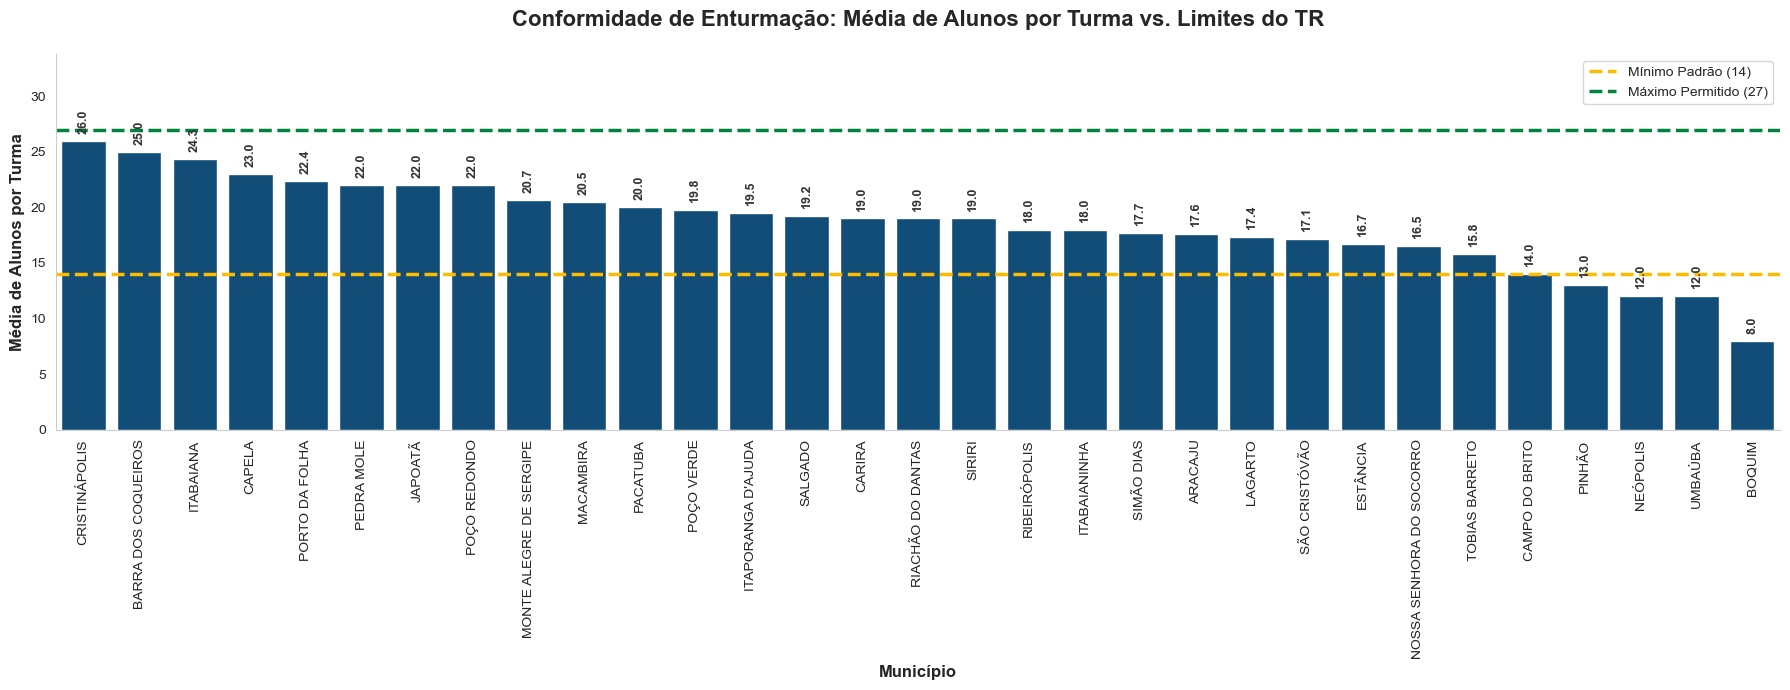

Gráfico de metas de enturmação gerado e salvo com sucesso.


In [47]:
# Agrupamento e cálculo da média de alunos por turma por município
resumo_metas = df_turmas.groupby('municipio', observed=True).agg(
    total_turmas=('turma', 'count'),
    media_alunos_turma=('qtd_alfabetizandos', 'mean')
).reset_index()

# Ordenando do maior para o menor para facilitar a visualização
resumo_metas = resumo_metas.sort_values('media_alunos_turma', ascending=False)

# Configuração do Gráfico
fig, ax = plt.subplots(figsize=(18, 7))

# Usaremos a cor Azul (#005088) como padrão
sns.barplot(
    data=resumo_metas, 
    x='municipio', 
    y='media_alunos_turma', 
    color=cores_pba[0], 
    ax=ax
)

# Adicionando as Linhas de Meta do TR
ax.axhline(14, color=cores_pba[1], linestyle='--', linewidth=2.5, label='Mínimo Padrão (14)') # Amarelo
ax.axhline(27, color=cores_pba[2], linestyle='--', linewidth=2.5, label='Máximo Permitido (27)') # Verde

# Adicionando os Rótulos de Dados nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=5, fontweight='bold', color='#333333', fontsize=9, rotation=90)

# Ajustes Estéticos
ax.set_title('Conformidade de Enturmação: Média de Alunos por Turma vs. Limites do TR', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Município', fontsize=12, fontweight='bold')
ax.set_ylabel('Média de Alunos por Turma', fontsize=12, fontweight='bold')
plt.xticks(rotation=90)

# Ajuste do limite Y para não cortar os rótulos
ax.set_ylim(0, resumo_metas['media_alunos_turma'].max() * 1.3)

ax.legend(loc='upper right', frameon=True)
sns.despine()
plt.tight_layout()

# Salvando o Gráfico
nome_grafico_8 = '8_metas_enturmacao_municipio.png'
caminho_grafico_8 = os.path.join(dir_graficos, nome_grafico_8)
plt.savefig(caminho_grafico_8, dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico de metas de enturmação gerado e salvo com sucesso.")


## 5. Monitoramento de Frequência e Risco de Evasão

A retenção do alfabetizando é um dos maiores desafios da EJA (Educação de Jovens e Adultos). O monitoramento da frequência é o indicador antecedente primário para o risco de evasão.

**Critério de Análise:**
* O índice mínimo de aceitação padrão em programas educacionais do estado costuma ser de **75% de frequência**. 
* Abaixo desse limite, a coordenação local deve acionar a estratégia de busca ativa.

*Nota: A taxa é calculada dividindo o número de presenças computadas pela quantidade de aulas dadas na turma até o momento do snapshot.*

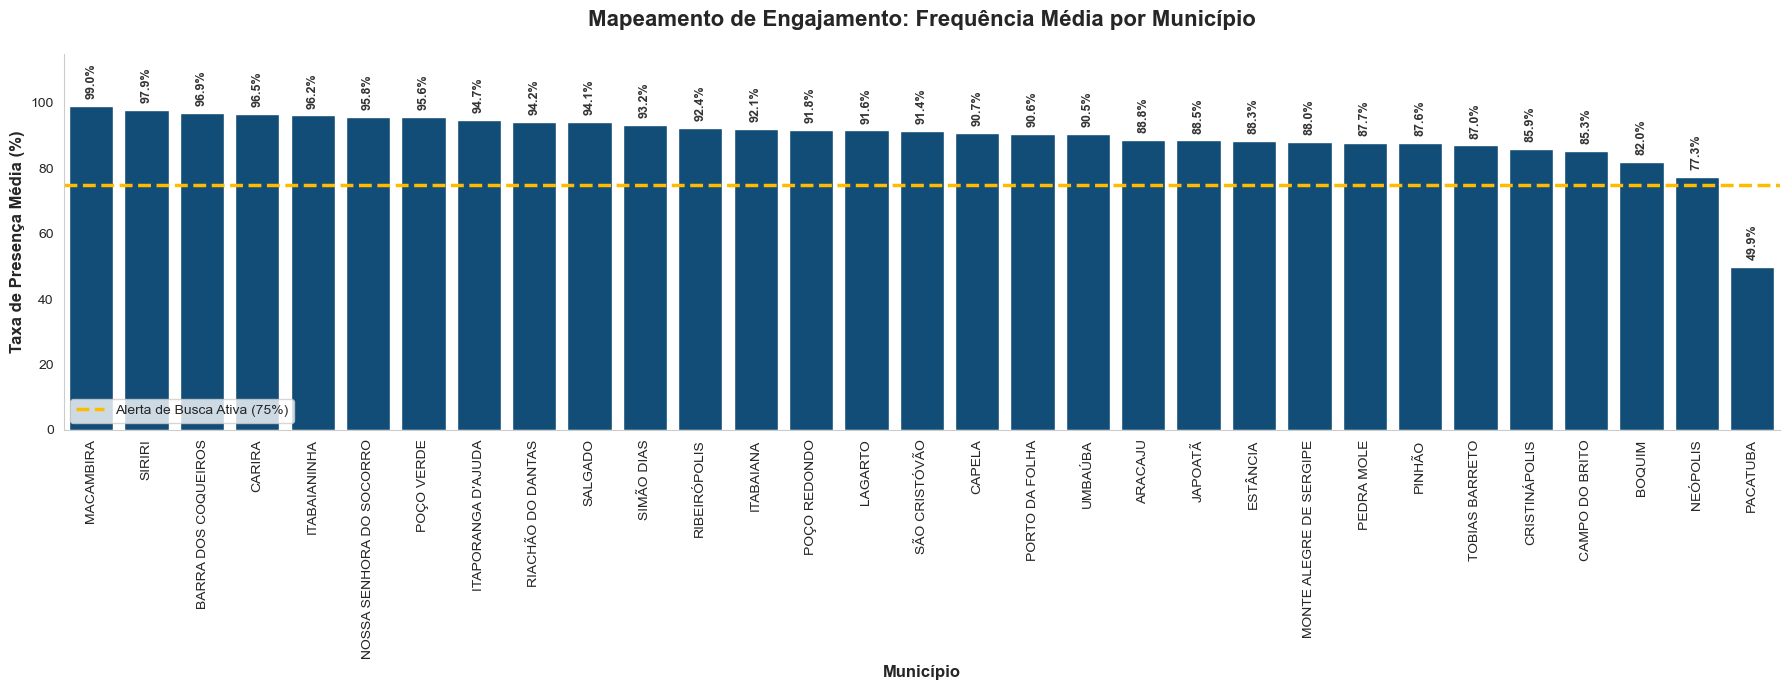

ALERTA EXECUTIVO:
Total de alunos com frequência abaixo de 75%: 226 (8.8% da amostra ativa).
Recomenda-se exportar a lista nominal destes alfabetizandos para os coordenadores locais.


In [48]:
# Tratamento e Cálculo da Taxa de Frequência
# Usamos np.where para evitar erro de divisão por zero caso haja turmas recém-criadas com 0 aulas dadas
df_pedagogico['taxa_frequencia'] = np.where(
    df_pedagogico['qtd_aulas_dadas_turma'] > 0,
    (df_pedagogico['qtd_presenca_alfabetizando'] / df_pedagogico['qtd_aulas_dadas_turma']) * 100,
    0
)

# Agrupamento por município para ver a frequência média
freq_muni = df_pedagogico.groupby('municipio', observed=True)['taxa_frequencia'].mean().reset_index()
freq_muni = freq_muni.sort_values('taxa_frequencia', ascending=False)

# Configuração do Gráfico
fig, ax = plt.subplots(figsize=(18, 7))

# Gráfico de barras na cor Azul institucional
sns.barplot(
    data=freq_muni, 
    x='municipio', 
    y='taxa_frequencia', 
    color=cores_pba[0], 
    ax=ax
)

# Linha de Alerta de Frequência (75%)
ax.axhline(75, color=cores_pba[1], linestyle='--', linewidth=2.5, label='Alerta de Busca Ativa (75%)') # Amarelo

# Adicionando os Rótulos de Dados
for container in ax.containers:
    # Usamos fmt='%.1f%%' para adicionar o símbolo de porcentagem no gráfico
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontweight='bold', color='#333333', fontsize=9, rotation=90)

# Ajustes Estéticos
ax.set_title('Mapeamento de Engajamento: Frequência Média por Município', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Município', fontsize=12, fontweight='bold')
ax.set_ylabel('Taxa de Presença Média (%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=90)

# Forçamos o eixo Y a ir até 115 para caber bem os rótulos de 100%
ax.set_ylim(0, 115) 

ax.legend(loc='lower left', frameon=True)
sns.despine()
plt.tight_layout()

# Salvando o Gráfico
nome_grafico_9 = ('9_frequencia_media_municipio.png')
caminho_grafico_9 = os.path.join(dir_graficos, nome_grafico_9)
plt.savefig(caminho_grafico_9, dpi=300, bbox_inches='tight')
plt.show()

# Extração Executiva: Contagem de Alunos Críticos
alunos_risco = df_pedagogico[df_pedagogico['taxa_frequencia'] < 75].shape[0]
percentual_risco = (alunos_risco / len(df_pedagogico)) * 100

print(f"ALERTA EXECUTIVO:")
print(f"Total de alunos com frequência abaixo de 75%: {alunos_risco} ({percentual_risco:.1f}% da amostra ativa).")
print("Recomenda-se exportar a lista nominal destes alfabetizandos para os coordenadores locais.")
